# 1. Introducción y Objetivo de la Preparación

En esta etapa del proyecto seguimos la metodología CRISP-DM, ubicándonos en la fase de Preparación de los Datos. El objetivo principal de este notebook es transformar y construir un dataset que esté listo para su uso en la fase de modelado, garantizando que los datos sean relevantes, consistentes y estén estructurados de manera óptima para entrenar modelos de machine learning.

Durante la fase previa (Comprensión de los Datos), identificamos múltiples fuentes de información relevantes: train.csv, test.csv, historical_transactions.csv, new_merchant_transactions.csv y merchants.csv. También detectamos distintos problemas de calidad de datos, como valores faltantes, outliers, y estructuras que requerían integrarse.

Por tanto, en esta notebook ejecutaremos las tareas necesarias para:

- Seleccionar atributos pertinentes para el modelado desde las distintas fuentes.

- Integrar adecuadamente las tablas relacionales (joins y agregaciones).

- Limpiar los datos detectados como problemáticos.

- Generar nuevas variables a partir del comportamiento transaccional de los usuarios.

- Transformar el dataset final a un formato y estructura compatibles con algoritmos de modelado.

El resultado final será un dataset preparado y curado que contenga una representación sintética de cada tarjeta (card_id), con variables numéricas y categóricas que permitan predecir de forma eficaz el loyalty score.

## Resumen de decisiones tomadas durante la fase de comprensión de los datos (por ejemplo, limpieza, selección de atributos).
Durante la fase de comprensión de los datos se analizaron las distintas fuentes de información provistas por Elo: datos de clientes (train.csv), transacciones históricas (historical_transactions.csv), transacciones recientes (new_merchant_transactions.csv) y características de los comercios (merchants.csv). Este análisis permitió identificar patrones clave, valores ausentes, relaciones entre variables y posibles outliers.

En base a los hallazgos anteriores, la fase de preparación de datos tiene como objetivo transformar estos datos crudos en un conjunto estructurado, limpio y listo para alimentar modelos de aprendizaje automático supervisado. Las principales decisiones tomadas que guían esta etapa son:

- El score de lealtad (target) es una variable continua y será predicho mediante un modelo de regresión.

- Se seleccionaron variables relevantes de cada archivo, considerando tanto su correlación potencial con la variable objetivo como su valor semántico en el contexto del negocio.

- Se detectaron variables con valores faltantes y outliers, que requerirán tratamiento adecuado.

- Se observó que muchas variables relevantes provienen de las transacciones, por lo que se realizarán agregaciones por cliente (card_id) para construir una matriz de datos con un registro por cliente.

- Las variables temporales tienen potencial para capturar estacionalidad, antigüedad y frecuencia, por lo que serán transformadas y derivadas.

- Se aplicará codificación a variables categóricas y se descartarán aquellas con baja varianza o sin valor informativo.

In [1]:
import pandas as pd
import polars as pl

import warnings
warnings.filterwarnings('ignore')

train = pl.read_csv("src/train.csv", try_parse_dates=True)
historical = pl.read_csv("src/historical_transactions.csv", try_parse_dates=True)
new_merchant = pl.read_csv("src/new_merchant_transactions.csv", try_parse_dates=True)
merchants = pl.read_csv("src/merchants.csv")

# train = pd.read_csv("src/train.csv", parse_dates=["first_active_month"])
# historical = pd.read_csv("src/historical_transactions.csv", parse_dates=["purchase_date"])
# new_merchant = pd.read_csv("src/new_merchant_transactions.csv", parse_dates=["purchase_date"])
# merchants = pd.read_csv("src/merchants.csv")

# 2. Selección de Datos

## Variables del archivo train.csv
- card_id: Identificador único del cliente. Será la clave principal para unir los datasets.

- first_active_month: Se utilizará para derivar la antigüedad del cliente.

- feature_1, feature_2: Variables categóricas internas provistas por Elo. Si bien su significado exacto no está documentado, muestran cierta variabilidad entre clientes y potencialmente capturan preferencias o segmentaciones internas.

Estas variables representan el punto de partida del cliente en la plataforma y pueden capturar segmentaciones internas o ciclos de vida que impactan en su lealtad futura.

In [2]:
train_selected = train.select(["card_id", "first_active_month", "feature_1", "feature_2", "target"])
train_selected.write_csv("src/select_data/train_selected.csv")
train_selected.head()

# train_selected = train[["card_id", "first_active_month", "feature_1", "feature_2", "target"]]
# train_selected.to_csv("src/select_data/train_selected.csv", index=False)
# train_selected.head()

card_id,first_active_month,feature_1,feature_2,target
str,str,i64,i64,f64
"""C_ID_92a2005557""","""2017-06""",5,2,-0.820283
"""C_ID_3d0044924f""","""2017-01""",4,1,0.392913
"""C_ID_d639edf6cd""","""2016-08""",2,2,0.688056
"""C_ID_186d6a6901""","""2017-09""",4,3,0.1424952
"""C_ID_cdbd2c0db2""","""2017-11""",1,3,-0.159749


## Variables derivadas del archivo historical_transactions.csv (agregadas por card_id)
- card_id
- purchase_date: Se extraerán variables de tiempo como antigüedad de la última compra, dispersión temporal entre compras y estacionalidad.
- authorized_flag: Porcentaje de transacciones aprobadas. Mide fiabilidad del cliente.
- installments: Agregado como promedio, mediana y proporción de pagos a cuotas. Refleja el tipo de consumo (efectivo vs crédito).
- merchant_category_id
- merchant_id
- purchase_amount: Se agregará como total, promedio, desviación estándar y percentiles. Mide el volumen histórico de gasto.
#### Antiguo se va eliminar
- purchase_amount: Se agregará como total, promedio, desviación estándar y percentiles. Mide el volumen histórico de gasto.

- installments: Agregado como promedio, mediana y proporción de pagos a cuotas. Refleja el tipo de consumo (efectivo vs crédito).

- purchase_date: Se extraerán variables de tiempo como antigüedad de la última compra, dispersión temporal entre compras y estacionalidad.

- month_lag: Permite agrupar transacciones por su antigüedad relativa.

- authorized_flag: Porcentaje de transacciones aprobadas. Mide fiabilidad del cliente.


Estas variables son fundamentales para entender el comportamiento histórico del cliente, sus patrones de gasto, regularidad y preferencias. Permiten inferir su valor y fidelidad previa al sistema de Elo.

In [3]:
historical_selected = historical.select([
    "card_id", 
    "purchase_date", 
    "authorized_flag", 
    "installments", 
    "merchant_category_id",
    "merchant_id", 
    "purchase_amount"
])
historical_selected.write_csv("src/select_data/historical_selected.csv")
historical_selected.head()

card_id,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount
str,datetime[μs],str,i64,i64,str,f64
"""C_ID_4e6213e9bc""",2017-06-25 15:33:07,"""Y""",0,80,"""M_ID_e020e9b302""",-0.703331
"""C_ID_4e6213e9bc""",2017-07-15 12:10:45,"""Y""",0,367,"""M_ID_86ec983688""",-0.733128
"""C_ID_4e6213e9bc""",2017-08-09 22:04:29,"""Y""",0,80,"""M_ID_979ed661fc""",-0.720386
"""C_ID_4e6213e9bc""",2017-09-02 10:06:26,"""Y""",0,560,"""M_ID_e6d5ae8ea6""",-0.735352
"""C_ID_4e6213e9bc""",2017-03-10 01:14:19,"""Y""",0,80,"""M_ID_e020e9b302""",-0.722865


In [4]:
# historical_selected = historical[
#     ["card_id", "purchase_date", "authorized_flag", "installments", "merchant_category_id",
#      "merchant_id", "purchase_amount"]
# ]
# historical_selected.to_csv("src/select_data/historical_selected.csv", index=False)

# historical_selected.head()

In [5]:
new_merchant_selected = new_merchant.select([
    "card_id", 
    "purchase_date", 
    "authorized_flag", 
    "installments", 
    "merchant_category_id",
    "merchant_id", 
    "purchase_amount"
])
new_merchant_selected.write_csv("src/select_data/new_merchant_selected.csv")
new_merchant_selected.head()

# new_merchant_selected = new_merchant[
#     ["card_id", "purchase_date", "authorized_flag", "installments", "merchant_category_id",
#      "merchant_id", "purchase_amount"]
# ]
# new_merchant_selected.to_csv("src/select_data/new_merchant_selected.csv", index=False)

# new_merchant_selected.head()

card_id,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount
str,datetime[μs],str,i64,i64,str,f64
"""C_ID_415bb3a509""",2018-03-11 14:57:36,"""Y""",1,307,"""M_ID_b0c793002c""",-0.557574
"""C_ID_415bb3a509""",2018-03-19 18:53:37,"""Y""",1,307,"""M_ID_88920c89e8""",-0.56958
"""C_ID_415bb3a509""",2018-04-26 14:08:44,"""Y""",1,507,"""M_ID_ad5237ef6b""",-0.551037
"""C_ID_415bb3a509""",2018-03-07 09:43:21,"""Y""",1,661,"""M_ID_9e84cda3b1""",-0.671925
"""C_ID_ef55cf8d4b""",2018-03-22 21:07:53,"""Y""",1,166,"""M_ID_3c86fa3831""",-0.659904


## Variables derivadas del archivo merchants.csv
- Misma estructura y tratamiento que historical_transactions, pero se analizarán como indicadores de comportamiento reciente (últimos comercios visitados).

Permiten medir el comportamiento del cliente frente a nuevos comercios, lo que es clave para inferir respuesta a campañas, apertura al cambio y potencial de exploración comercial. Clientes activos con nuevos comercios pueden tener mayor probabilidad de lealtad futura.

## Variables del archivo merchants.csv (vinculadas vía merchant_id)
- merchant_id
- merchant_group_id
- merchant_category_id
- most_recent_sales_range: Codifican la intensidad comercial más reciente. Se codificarán ordinalmente.
- most_recent_purchases_range: Codifican la intensidad comercial más reciente. Se codificarán ordinalmente.
- active_months_lag12: Cantidad de meses activos en los últimos 12 meses
#### Antiguo se va eliminar
- avg_sales_lag3, avg_sales_lag6, etc.: Indicadores del dinamismo del comercio.

- most_recent_sales_range, most_recent_purchases_range: Codifican la intensidad comercial más reciente. Se codificarán ordinalmente.

- merchant_category_id, category_1, category_4: Se cruzarán con las transacciones para crear representaciones de afinidad del cliente con ciertas categorías o tipos de comercio.

El tipo de comercio influye en el patrón de compra del cliente. Al cruzarlo con los hábitos del cliente, se pueden obtener variables que midan la compatibilidad cliente–comercio.

In [6]:
merchants_selected = merchants.select([
    "merchant_id",
    "merchant_group_id",
    "merchant_category_id",
    "most_recent_sales_range",
    "most_recent_purchases_range",
    "active_months_lag12"
])
merchants_selected.write_csv("src/select_data/merchants_selected.csv")
merchants_selected.head()

# merchants_selected = merchants[
#     ["merchant_id", "merchant_group_id", "merchant_category_id", "most_recent_sales_range", 
#      "most_recent_purchases_range", "active_months_lag12"]
# ]
# merchants_selected.to_csv("src/select_data/merchants_selected.csv", index=False)

# merchants_selected.head()

merchant_id,merchant_group_id,merchant_category_id,most_recent_sales_range,most_recent_purchases_range,active_months_lag12
str,i64,i64,str,str,i64
"""M_ID_838061e48c""",8353,792,"""E""","""E""",12
"""M_ID_9339d880ad""",3184,840,"""E""","""E""",12
"""M_ID_e726bbae1e""",447,690,"""E""","""E""",2
"""M_ID_a70e9c5f81""",5026,792,"""E""","""E""",12
"""M_ID_64456c37ce""",2228,222,"""E""","""E""",12


## Variables descartadas o no priorizadas
- subsector_id, category_name: Alta cardinalidad, bajo control semántico. Serán descartadas a menos que pruebas futuras muestren valor predictivo.

- Variables como merchant_id y merchant_group_id no se usarán directamente, pero servirán como llaves de agregación.

- Transacciones no autorizadas: Si representan un porcentaje muy pequeño (<5%), pueden ser descartadas por ruido.

- Variables con más del 90% de valores nulos o con baja varianza.

## Enfoque adicional orientado al producto
- Clientes con gran diversidad de categorías y alta frecuencia reciente podrían representar perfiles altamente leales o promotores. Este tipo de hipótesis será validada en el modelado.

- Se prestará atención a variables que permitan explicar no solo el monto gastado, sino el nivel de compromiso con la plataforma, como uso recurrente, exploración de nuevos comercios y respuesta a promociones.

# 3. Limpieza de los Datos

## Imputación de valores faltantes.
La imputación de valores faltantes es una técnica utilizada en la limpieza de datos para reemplazar los valores ausentes (NaN o null) en un dataset por valores estimados o calculados. El objetivo es evitar perder información valiosa y permitir que los algoritmos de análisis o modelado funcionen correctamente, ya que muchos no pueden manejar datos faltantes.

In [7]:
def verificar_nulos(df, nombre):
    print(f"\nValores nulos en: {nombre}")
    nulos = df.null_count().to_dict(as_series=False)
    # Si los valores son listas, extrae el primer elemento
    print({col: (val[0] if isinstance(val, list) else val) for col, val in nulos.items()})
    
    


# def mostrar_nulos(df, nombre):
#     print(f"\nValores nulos en: {nombre}")
#     existe_nulos = df.isnull().sum().sum() > 0
#     print(df.isnull().sum()[df.isnull().sum() > 0] if existe_nulos else "No se encontraron valores nulos en el dataset")


In [8]:
verificar_nulos(train_selected, "train_selected")
verificar_nulos(historical_selected, "historical_selected")
verificar_nulos(new_merchant_selected, "new_merchant_selected")
verificar_nulos(merchants_selected, "merchants_selected")

# mostrar_nulos(train_selected, "train_selected")
# mostrar_nulos(historical_selected, "historical_selected")
# mostrar_nulos(new_merchant_selected, "new_merchant_selected")
# mostrar_nulos(merchants_selected, "merchants_selected")



Valores nulos en: train_selected
{'card_id': 0, 'first_active_month': 0, 'feature_1': 0, 'feature_2': 0, 'target': 0}

Valores nulos en: historical_selected
{'card_id': 0, 'purchase_date': 0, 'authorized_flag': 0, 'installments': 0, 'merchant_category_id': 0, 'merchant_id': 138481, 'purchase_amount': 0}

Valores nulos en: new_merchant_selected
{'card_id': 0, 'purchase_date': 0, 'authorized_flag': 0, 'installments': 0, 'merchant_category_id': 0, 'merchant_id': 26216, 'purchase_amount': 0}

Valores nulos en: merchants_selected
{'merchant_id': 0, 'merchant_group_id': 0, 'merchant_category_id': 0, 'most_recent_sales_range': 0, 'most_recent_purchases_range': 0, 'active_months_lag12': 0}


### **Tratamiento de nulos en historical_selected**

In [9]:
def generar_moda(dataframe):
    df_freq = (
        dataframe
        .group_by(["card_id", "merchant_id"])
        .agg(pl.count().alias("count"))
    )
        
    df_mode = (
        df_freq
        .sort(["card_id", "count", "merchant_id"], descending=[False, True, True])
        .group_by("card_id")
        .agg(pl.col("merchant_id").first().alias("merchant_id_moda"))
    )

    return df_mode

df_mode_historical = generar_moda(historical_selected)
df_mode_historical.head(10)

card_id,merchant_id_moda
str,str
"""C_ID_00007093c1""","""M_ID_9400cf2342"""
"""C_ID_0001238066""","""M_ID_d17aabd756"""
"""C_ID_0001506ef0""","""M_ID_b1fc88154d"""
"""C_ID_0001793786""","""M_ID_923d57de8d"""
"""C_ID_000183fdda""","""M_ID_f9cfe0a43b"""
"""C_ID_00024e244b""","""M_ID_8f71be2af9"""
"""C_ID_0002709b5a""","""M_ID_543dd11ce2"""
"""C_ID_00027503e2""","""M_ID_8de747a1c2"""
"""C_ID_000298032a""","""M_ID_8978193c15"""


In [10]:
def reemplazar_moda_in_transactions(dataframe_original, df_mode):
    # Selecciona solo las columnas necesarias (sin persist ni count)
    df_moda_util = df_mode.select(['card_id', 'merchant_id_moda'])

    # Realiza el join usando Polars
    vdf_final = dataframe_original.join(df_moda_util, on="card_id", how="left")

    # Si merchant_id es nulo, reemplázalo por merchant_id_moda
    vdf_final = vdf_final.with_columns([
        pl.when(pl.col("merchant_id").is_null())
        .then(pl.col("merchant_id_moda"))
        .otherwise(pl.col("merchant_id"))
        .alias("merchant_id")
    ]).drop("merchant_id_moda")
    
    return vdf_final

In [11]:
vdf_historical = reemplazar_moda_in_transactions(historical_selected, df_mode_historical)
verificar_nulos(vdf_historical, "vdf_historical")


Valores nulos en: vdf_historical
{'card_id': 0, 'purchase_date': 0, 'authorized_flag': 0, 'installments': 0, 'merchant_category_id': 0, 'merchant_id': 6262, 'purchase_amount': 0}


In [12]:
# # mostrar de vdf_historical solo los que tengan merchant_id nulo
# vdf_historical_nulls = vdf_historical.filter(pl.col("merchant_id").is_null())
# # de vdf_historical, verificar si se repiten el card_id
# vdf_historical_repeated = vdf_historical_nulls.group_by("card_id").agg(pl.count().alias("count")).filter(pl.col("count") > 1)
# #vdf_historical_repeated

# # mostrar en una tabla los registros que tengan de card_id = "C_ID_69470cbe80" de vdf_historical_nulls
# #vdf_historical_nulls.filter(pl.col("card_id") == "C_ID_69470cbe80")

# Eliminar todas las filas que tengan merchant_id nulo de vdf_historical
vdf_historical = vdf_historical.filter(pl.col("merchant_id").is_not_null())
vdf_historical



card_id,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount
str,datetime[μs],str,i64,i64,str,f64
"""C_ID_4e6213e9bc""",2017-06-25 15:33:07,"""Y""",0,80,"""M_ID_e020e9b302""",-0.703331
"""C_ID_4e6213e9bc""",2017-07-15 12:10:45,"""Y""",0,367,"""M_ID_86ec983688""",-0.733128
"""C_ID_4e6213e9bc""",2017-08-09 22:04:29,"""Y""",0,80,"""M_ID_979ed661fc""",-0.720386
"""C_ID_4e6213e9bc""",2017-09-02 10:06:26,"""Y""",0,560,"""M_ID_e6d5ae8ea6""",-0.735352
"""C_ID_4e6213e9bc""",2017-03-10 01:14:19,"""Y""",0,80,"""M_ID_e020e9b302""",-0.722865
…,…,…,…,…,…,…
"""C_ID_2863d2fa95""",2017-01-20 08:52:04,"""Y""",1,360,"""M_ID_edd92b6720""",-0.632706
"""C_ID_2863d2fa95""",2017-02-20 04:40:50,"""Y""",1,360,"""M_ID_edd92b6720""",-0.632706
"""C_ID_5c240d6e3c""",2017-12-26 18:37:51,"""Y""",0,278,"""M_ID_9cdcfe8673""",-0.65774


Verificamos la limpieza

In [13]:
verificar_nulos(vdf_historical, "vdf_historical sin nulos en merchant_id")


Valores nulos en: vdf_historical sin nulos en merchant_id
{'card_id': 0, 'purchase_date': 0, 'authorized_flag': 0, 'installments': 0, 'merchant_category_id': 0, 'merchant_id': 0, 'purchase_amount': 0}


### **Tratamiento de nulos en new_merchant_selected**

In [14]:
df_mode_new_historical = generar_moda(new_merchant_selected)
df_mode_new_historical.head(10)

card_id,merchant_id_moda
str,str
"""C_ID_00007093c1""","""M_ID_08f01305af"""
"""C_ID_0001238066""",null
"""C_ID_0001506ef0""",null
"""C_ID_0001793786""","""M_ID_f86439cec0"""
"""C_ID_000183fdda""","""M_ID_f7197e94a6"""
"""C_ID_0002709b5a""","""M_ID_bee1dd91a9"""
"""C_ID_000298032a""","""M_ID_c33d6e0856"""
"""C_ID_0002ba3c2e""","""M_ID_f598656829"""
"""C_ID_0002c7c2c1""","""M_ID_d74eeb0c7a"""


In [15]:
vdf_new_historical = reemplazar_moda_in_transactions(historical_selected, df_mode_new_historical)
verificar_nulos(vdf_new_historical, "vdf_new_historical")


Valores nulos en: vdf_new_historical
{'card_id': 0, 'purchase_date': 0, 'authorized_flag': 0, 'installments': 0, 'merchant_category_id': 0, 'merchant_id': 6053, 'purchase_amount': 0}


In [16]:
vdf_new_historical = vdf_new_historical.filter(pl.col("merchant_id").is_not_null())
vdf_new_historical

card_id,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount
str,datetime[μs],str,i64,i64,str,f64
"""C_ID_4e6213e9bc""",2017-06-25 15:33:07,"""Y""",0,80,"""M_ID_e020e9b302""",-0.703331
"""C_ID_4e6213e9bc""",2017-07-15 12:10:45,"""Y""",0,367,"""M_ID_86ec983688""",-0.733128
"""C_ID_4e6213e9bc""",2017-08-09 22:04:29,"""Y""",0,80,"""M_ID_979ed661fc""",-0.720386
"""C_ID_4e6213e9bc""",2017-09-02 10:06:26,"""Y""",0,560,"""M_ID_e6d5ae8ea6""",-0.735352
"""C_ID_4e6213e9bc""",2017-03-10 01:14:19,"""Y""",0,80,"""M_ID_e020e9b302""",-0.722865
…,…,…,…,…,…,…
"""C_ID_2863d2fa95""",2017-01-20 08:52:04,"""Y""",1,360,"""M_ID_edd92b6720""",-0.632706
"""C_ID_2863d2fa95""",2017-02-20 04:40:50,"""Y""",1,360,"""M_ID_edd92b6720""",-0.632706
"""C_ID_5c240d6e3c""",2017-12-26 18:37:51,"""Y""",0,278,"""M_ID_9cdcfe8673""",-0.65774


Verificamos la limpieza

In [17]:
verificar_nulos(vdf_new_historical, "vdf_historical sin nulos en merchant_id")


Valores nulos en: vdf_historical sin nulos en merchant_id
{'card_id': 0, 'purchase_date': 0, 'authorized_flag': 0, 'installments': 0, 'merchant_category_id': 0, 'merchant_id': 0, 'purchase_amount': 0}


### Validacion de existencias de claves foraneas en historical

In [18]:
def verificar_merchants_existentes(vdf_historical_unique, merchants_selected):
    missing_merchants = vdf_historical_unique.filter(
        ~pl.col("merchant_id").is_in(merchants_selected["merchant_id"])
    )
    return missing_merchants

In [19]:
def verificar_cards_existentes(vdf_historical_unique, train_selected):
    missing_cards = vdf_historical_unique.filter(
        ~pl.col("card_id").is_in(train_selected["card_id"])
    )
    return missing_cards

In [20]:
# del dataframe vdf_historical crear una nueva tabla que contenga todos los merchant_id sin duplicados
vdf_historical_unique_merchants = (
    vdf_historical
    .select("merchant_id")
    .unique()
)


missing_merchants = verificar_merchants_existentes(vdf_historical_unique_merchants, merchants_selected)

print("Todos los merchant_id de Historical existen"if missing_merchants.is_empty() else "Hay merchant_id de Historical que no existen en Merchants")



Todos los merchant_id de Historical existen


Se verificco la existencia de todos los merchant_id de historical, por lo cual no necesita de una limpieza

In [21]:
# del dataframe vdf_historical crear una nueva tabla que contenga todos los merchant_id sin duplicados
vdf_historical_unique_cards = (
    vdf_historical
    .select("card_id")
    .unique()
)

missing_cards = verificar_cards_existentes(train_selected, vdf_historical_unique_cards)

print("Todos los card_id de Historical existen"if missing_cards.is_empty() else "Hay card_id de Historical que no existen en Train")



Todos los card_id de Historical existen


### Validacion de existencias de claves foraneas en new historical

In [22]:

vdf_new_historical_unique_merchants = (
    vdf_new_historical
    .select("merchant_id")
    .unique()
)

missing_merchants_new = verificar_merchants_existentes(vdf_new_historical_unique_merchants, merchants_selected)

print("Todos los merchant_id de Historical existen"if missing_merchants_new.is_empty() else "Hay merchant_id de Historical que no existen en Merchants")


Todos los merchant_id de Historical existen


Se verificco la existencia de todos los merchant_id de new historical, por lo cual no necesita de una limpieza

In [23]:
# del dataframe vdf_historical crear una nueva tabla que contenga todos los merchant_id sin duplicados
vdf_new_historical_unique_cards = (
    vdf_new_historical
    .select("card_id")
    .unique()
)

missing_cards_new = verificar_cards_existentes(train_selected, vdf_new_historical_unique_cards)

print("Todos los card_id de Historical existen"if missing_cards_new.is_empty() else "Hay card_id de Historical que no existen en Train")



Todos los card_id de Historical existen


Guardamos el dataset 

In [24]:
vdf_historical.write_csv("src/clean_data/vdf_historical.csv")
vdf_new_historical.write_csv("src/clean_data/vdf_new_historical.csv")
train_selected.write_csv("src/clean_data/train_selected.csv")
merchants_selected.write_csv("src/clean_data/merchants_selected.csv")

## Corrección de valores erróneos, inconsistentes o duplicados.

In [ ]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
# Cargar los datos limpios
vdf_historical = pl.read_csv("src/clean_data/vdf_historical.csv", try_parse_dates=True)
vdf_new_historical = pl.read_csv("src/clean_data/vdf_new_historical.csv", try_parse_dates=True)
train_selected = pl.read_csv("src/clean_data/train_selected.csv", try_parse_dates=True)
merchants_selected = pl.read_csv("src/clean_data/merchants_selected.csv")

transaction = pl.concat([vdf_historical, vdf_new_historical], how="vertical")

In [7]:
import matplotlib.pyplot as plt
# crea una funcion para identificar filas duplicadas en un mismo dataframe de polars que recibe por parametro el dataframe
def identificar_duplicados(dataframe):
    duplicados = dataframe.group_by(dataframe.columns).agg(pl.count().alias("count")).filter(pl.col("count") > 1)
    return duplicados

# funcion que seleciona un dataframe y selecciona por un campo "date" para seleccionar el rango de fechas 2017-11 hasta 2018-04. Los parametros son "df" y "nombre_columna_fecha"
def filtrar_por_fecha(df, nombre_columna_fecha):
    fecha_inicio = pl.lit("2017-11-01").str.strptime(pl.Date)
    fecha_fin = pl.lit("2018-04-30").str.strptime(pl.Date)
    
    df_filtrado = df.filter(
        (pl.col(nombre_columna_fecha) >= fecha_inicio) & 
        (pl.col(nombre_columna_fecha) <= fecha_fin)
    )
    
    return df_filtrado

def eliminar_duplicados(dataframe):
    return dataframe.unique(subset=dataframe.columns)

def generar_boxplot(dataframe, column_name, title):
    plt.figure(figsize=(10, 6))
    dataframe.select(column_name).to_pandas().boxplot()
    plt.title(title)
    plt.ylabel(column_name)
    plt.show()


In [3]:
transaction = filtrar_por_fecha(transaction, "purchase_date")
transaction

card_id,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount
str,datetime[μs],str,i64,i64,str,f64
"""C_ID_4e6213e9bc""",2018-02-24 08:45:05,"""Y""",0,80,"""M_ID_50af771f8d""",-0.734887
"""C_ID_4e6213e9bc""",2017-11-18 20:05:55,"""Y""",0,80,"""M_ID_9d41786a50""",-0.657049
"""C_ID_4e6213e9bc""",2018-02-08 20:05:45,"""Y""",0,560,"""M_ID_7c5e93af2f""",-0.727929
"""C_ID_4e6213e9bc""",2018-02-07 12:19:33,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.725871
"""C_ID_4e6213e9bc""",2018-01-08 23:54:29,"""Y""",0,80,"""M_ID_4524a562f3""",-0.699725
…,…,…,…,…,…,…
"""C_ID_e49b1996b0""",2017-12-29 14:43:53,"""Y""",1,705,"""M_ID_b692f6f5d1""",-0.618747
"""C_ID_e49b1996b0""",2018-01-23 01:52:28,"""Y""",1,550,"""M_ID_09d7a200d1""",-0.656749
"""C_ID_e49b1996b0""",2018-02-07 18:17:01,"""Y""",1,130,"""M_ID_ea5d727248""",-0.694315


In [4]:
print(identificar_duplicados(train_selected))
print(identificar_duplicados(transaction))
print(identificar_duplicados(merchants_selected))

shape: (0, 6)
┌─────────┬────────────────────┬───────────┬───────────┬────────┬───────┐
│ card_id ┆ first_active_month ┆ feature_1 ┆ feature_2 ┆ target ┆ count │
│ ---     ┆ ---                ┆ ---       ┆ ---       ┆ ---    ┆ ---   │
│ str     ┆ str                ┆ i64       ┆ i64       ┆ f64    ┆ u32   │
╞═════════╪════════════════════╪═══════════╪═══════════╪════════╪═══════╡
└─────────┴────────────────────┴───────────┴───────────┴────────┴───────┘
shape: (11_388_993, 8)
┌────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────┐
│ card_id    ┆ purchase_d ┆ authorized ┆ installmen ┆ merchant_c ┆ merchant_i ┆ purchase_a ┆ count │
│ ---        ┆ ate        ┆ _flag      ┆ ts         ┆ ategory_id ┆ d          ┆ mount      ┆ ---   │
│ str        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ u32   │
│            ┆ datetime[μ ┆ str        ┆ i64        ┆ i64        ┆ str        ┆ f64        ┆       │
│            ┆

In [14]:
train_selected = eliminar_duplicados(train_selected)
transaction = eliminar_duplicados(transaction)
merchants_selected = eliminar_duplicados(merchants_selected)

In [15]:
print(identificar_duplicados(train_selected))
print(identificar_duplicados(transaction))
print(identificar_duplicados(merchants_selected))

shape: (0, 6)
┌─────────┬────────────────────┬───────────┬───────────┬────────┬───────┐
│ card_id ┆ first_active_month ┆ feature_1 ┆ feature_2 ┆ target ┆ count │
│ ---     ┆ ---                ┆ ---       ┆ ---       ┆ ---    ┆ ---   │
│ str     ┆ str                ┆ i64       ┆ i64       ┆ f64    ┆ u32   │
╞═════════╪════════════════════╪═══════════╪═══════════╪════════╪═══════╡
└─────────┴────────────────────┴───────────┴───────────┴────────┴───────┘
shape: (0, 8)
┌─────────┬─────────────┬─────────────┬─────────────┬────────────┬────────────┬────────────┬───────┐
│ card_id ┆ purchase_da ┆ authorized_ ┆ installment ┆ merchant_c ┆ merchant_i ┆ purchase_a ┆ count │
│ ---     ┆ te          ┆ flag        ┆ s           ┆ ategory_id ┆ d          ┆ mount      ┆ ---   │
│ str     ┆ ---         ┆ ---         ┆ ---         ┆ ---        ┆ ---        ┆ ---        ┆ u32   │
│         ┆ datetime[μs ┆ str         ┆ i64         ┆ i64        ┆ str        ┆ f64        ┆       │
│         ┆ ]          

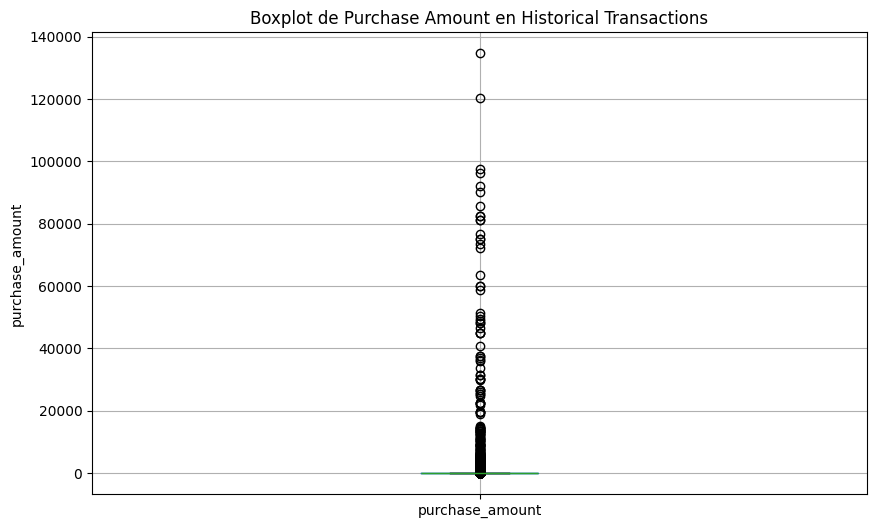

In [20]:
generar_boxplot(transaction, "purchase_amount", "Boxplot de Purchase Amount en Historical Transactions")

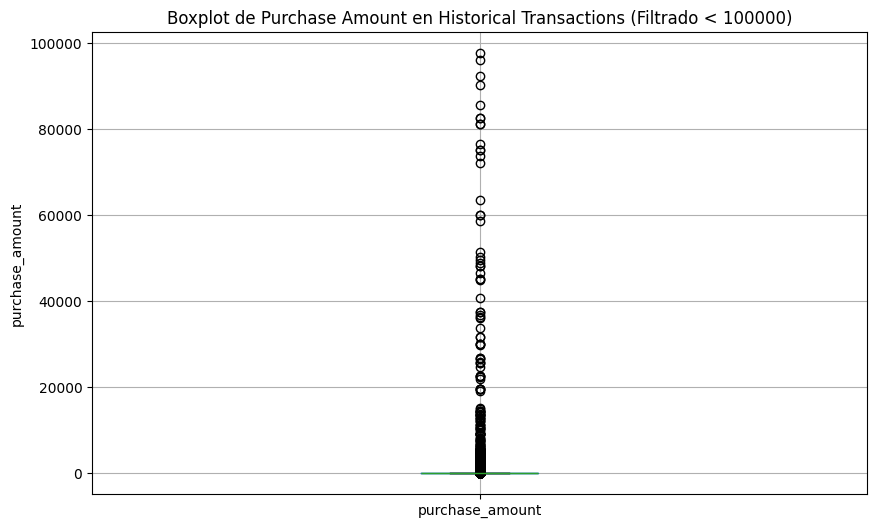

In [25]:
# seleccionar todas las filas que sean menores a 100000 de purchase_amount del dataframe transaction
transaction = transaction.filter(pl.col("purchase_amount") < 100000)
generar_boxplot(transaction, "purchase_amount", "Boxplot de Purchase Amount en Historical Transactions (Filtrado < 100000)")

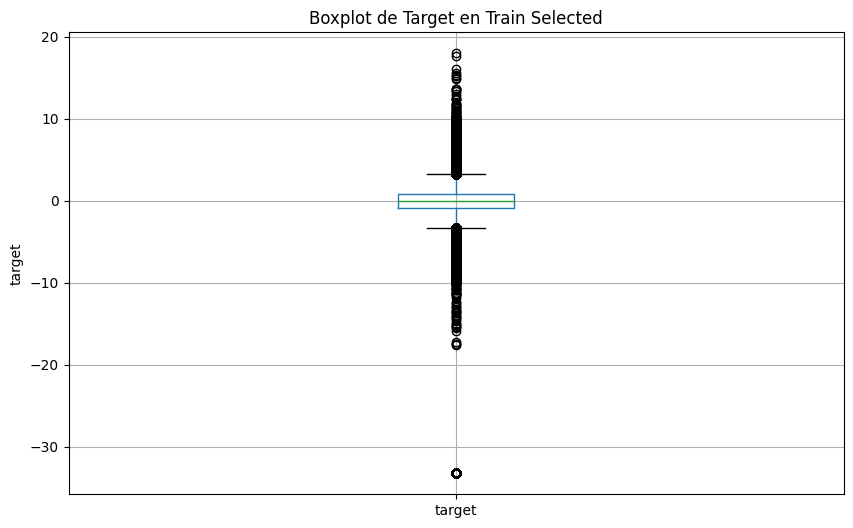

In [22]:
generar_boxplot(train_selected, "target", "Boxplot de Target en Train Selected")

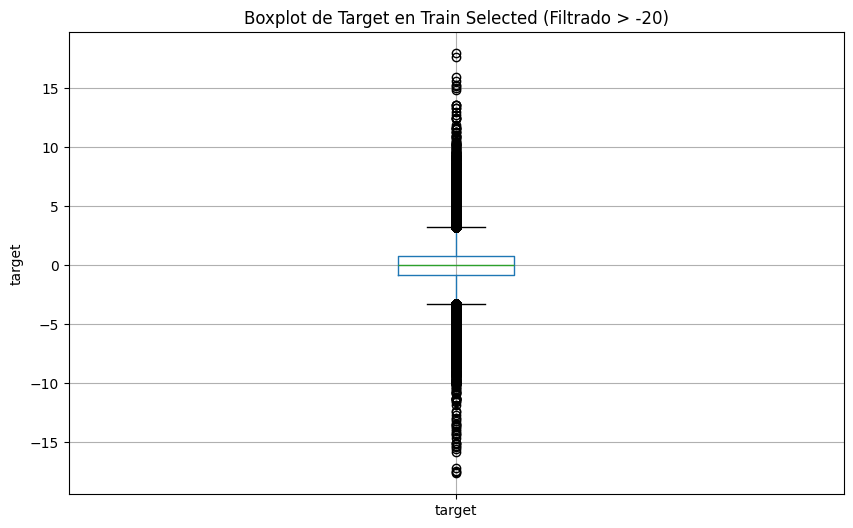

In [24]:
train_selected = train_selected.filter(pl.col("target") > -20)
generar_boxplot(train_selected, "target", "Boxplot de Target en Train Selected (Filtrado > -20)")

In [27]:
# guardar los dataframes finales
transaction.write_csv("src/final_data/transaction.csv")
train_selected.write_csv("src/final_data/train_selected.csv")
merchants_selected.write_csv("src/final_data/merchants_selected.csv")

In [24]:
# SELECCIONAR LA COLUMNA DE CARD_ID DE train_selected
train_card_ids = merchants_selected.select("merchant_id")

print(identificar_duplicados(train_card_ids))


shape: (41, 2)
┌─────────────────┬───────┐
│ merchant_id     ┆ count │
│ ---             ┆ ---   │
│ str             ┆ u32   │
╞═════════════════╪═══════╡
│ M_ID_645a6af169 ┆ 2     │
│ M_ID_a8767b29ef ┆ 2     │
│ M_ID_992a180b15 ┆ 4     │
│ M_ID_49b779bc8a ┆ 2     │
│ M_ID_00a6ca8a8a ┆ 2     │
│ …               ┆ …     │
│ M_ID_9b0ef314cf ┆ 2     │
│ M_ID_a55beb9d9a ┆ 2     │
│ M_ID_d123532c72 ┆ 4     │
│ M_ID_7251df88ad ┆ 2     │
│ M_ID_ebbdb42da6 ┆ 4     │
└─────────────────┴───────┘


In [8]:
# funcion que seleciona un dataframe y selecciona por un campo "date" para seleccionar el rango de fechas 2017-11 hasta 2018-04. Los parametros son "df" y "nombre_columna_fecha"
def filtrar_por_fecha(df, nombre_columna_fecha):
    fecha_inicio = pl.lit("2017-11-01").str.strptime(pl.Date)
    fecha_fin = pl.lit("2018-04-30").str.strptime(pl.Date)
    
    df_filtrado = df.filter(
        (pl.col(nombre_columna_fecha) >= fecha_inicio) & 
        (pl.col(nombre_columna_fecha) <= fecha_fin)
    )
    
    return df_filtrado

vdf_historical = filtrar_por_fecha(vdf_historical, "purchase_date")
vdf_new_historical = filtrar_por_fecha(vdf_new_historical, "purchase_date")


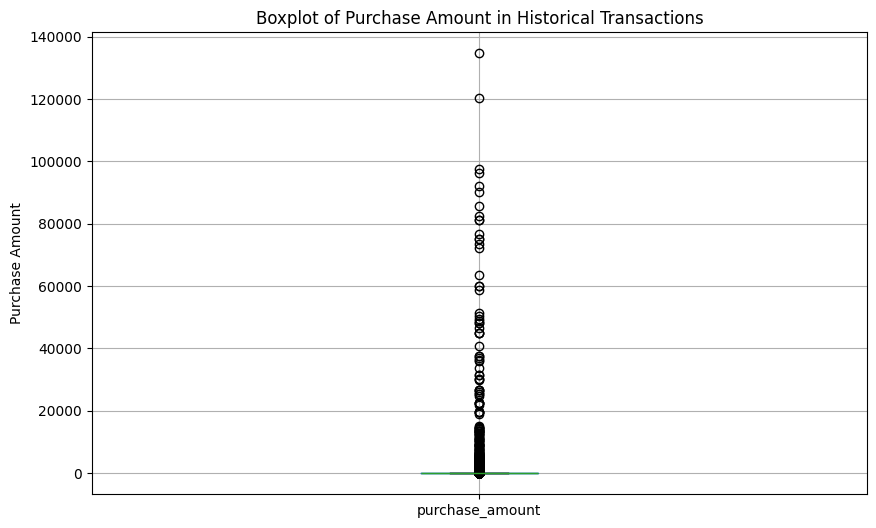

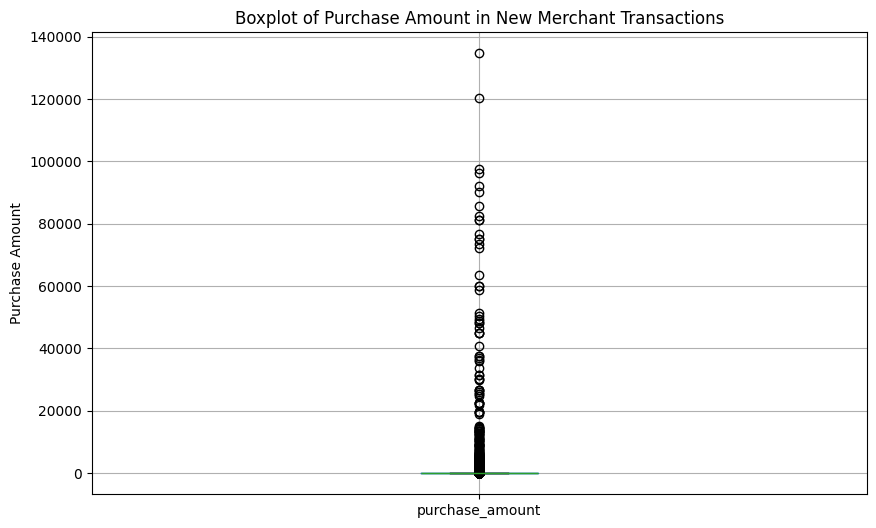

In [ ]:
#genera boxplots de la columana purchase_amount del dataframe de polars de vdf_historical y vdf_new_historical
import matplotlib.pyplot as plt
def generar_boxplot(dataframe, column, title):
    plt.figure(figsize=(10, 6))
    dataframe.select(column).to_pandas().boxplot()
    plt.title(title)
    plt.ylabel("Purchase Amount")
    plt.show()
generar_boxplot(vdf_historical, "Boxplot of Purchase Amount in Historical Transactions")
generar_boxplot(vdf_new_historical, "Boxplot of Purchase Amount in New Merchant Transactions")



In [11]:
print(identificar_duplicados(vdf_historical))
print(identificar_duplicados(vdf_new_historical))

shape: (85, 8)
┌────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────┐
│ card_id    ┆ purchase_d ┆ authorized ┆ installmen ┆ merchant_c ┆ merchant_i ┆ purchase_a ┆ count │
│ ---        ┆ ate        ┆ _flag      ┆ ts         ┆ ategory_id ┆ d          ┆ mount      ┆ ---   │
│ str        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ u32   │
│            ┆ datetime[μ ┆ str        ┆ i64        ┆ i64        ┆ str        ┆ f64        ┆       │
│            ┆ s]         ┆            ┆            ┆            ┆            ┆            ┆       │
╞════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════╡
│ C_ID_0041c ┆ 2017-11-03 ┆ N          ┆ 1          ┆ 705        ┆ M_ID_e3006 ┆ -0.68004   ┆ 2     │
│ 3242c      ┆ 00:00:00   ┆            ┆            ┆            ┆ 08e50      ┆            ┆       │
│ C_ID_cbe12 ┆ 2017-11-11 ┆ N          ┆ 0          ┆ 705        ┆ M_ID_b98d

In [12]:
# aplica el metodo de robus scaling para estandarizar la columna purchase_amount de vdf_historical y vdf_new_historical
from sklearn.preprocessing import RobustScaler
def aplicar_robust_scaler(dataframe):
    scaler = RobustScaler()
    # Convertir la columna a un formato adecuado para el escalado
    purchase_amount = dataframe.select("purchase_amount").to_pandas().values.reshape(-1, 1)
    # Aplicar el escalado
    scaled_values = scaler.fit_transform(purchase_amount)
    # Reemplazar la columna original con los valores escalados
    dataframe = dataframe.with_columns(pl.Series("purchase_amount", scaled_values.flatten()))
    return dataframe
vdf_historical = aplicar_robust_scaler(vdf_historical)
vdf_new_historical = aplicar_robust_scaler(vdf_new_historical)

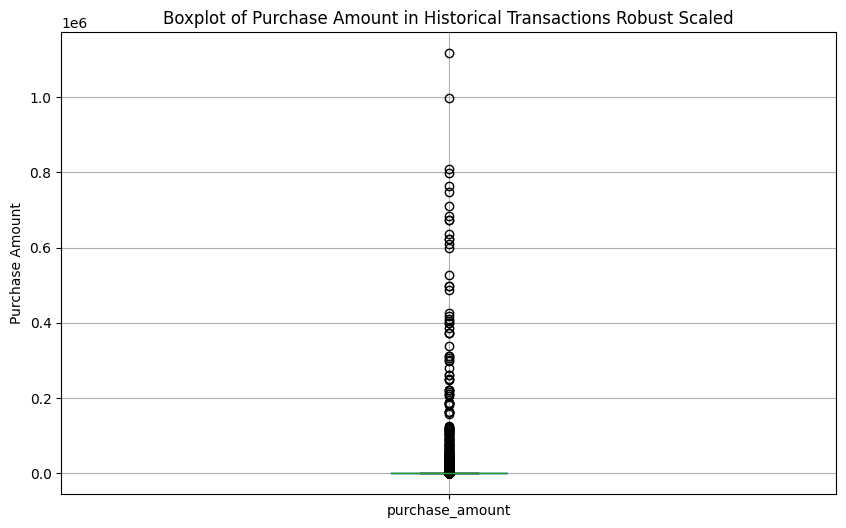

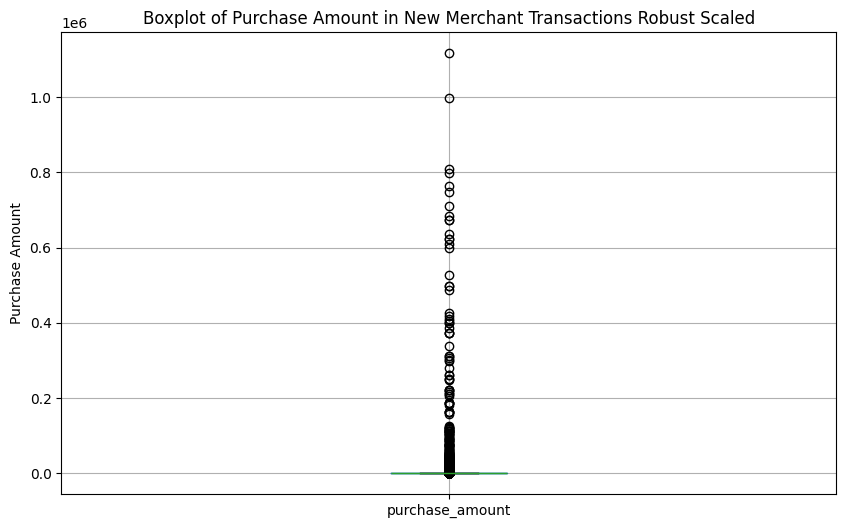

In [13]:
generar_boxplot(vdf_historical, "Boxplot of Purchase Amount in Historical Transactions Robust Scaled")
generar_boxplot(vdf_new_historical, "Boxplot of Purchase Amount in New Merchant Transactions Robust Scaled")

In [12]:
# funcion para eliminar duplicados en un dataframe de polars
def eliminar_duplicados(dataframe):
    return dataframe.unique(subset=dataframe.columns)
train_selected =eliminar_duplicados(train_selected)
vdf_historical =eliminar_duplicados(vdf_historical)
vdf_new_historical =eliminar_duplicados(vdf_new_historical)
merchants_selected = eliminar_duplicados(merchants_selected)

# # funcion para elimiar filas donde tienen el mismo merchant_id de un dataframe de polars
# def eliminar_duplicados_por_merchant_id(dataframe):
#     return dataframe.unique(subset=["merchant_id"])

# df_clean2 = eliminar_duplicados(merchants_selected)


In [ ]:
print(identificar_duplicados(train_selected))
print(identificar_duplicados(vdf_historical))
print(identificar_duplicados(vdf_new_historical))
print(identificar_duplicados(merchants_selected))

shape: (0, 7)
┌─────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬───────┐
│ merchant_id ┆ merchant_grou ┆ merchant_cate ┆ most_recent_ ┆ most_recent_ ┆ active_month ┆ count │
│ ---         ┆ p_id          ┆ gory_id       ┆ sales_range  ┆ purchases_ra ┆ s_lag12      ┆ ---   │
│ str         ┆ ---           ┆ ---           ┆ ---          ┆ nge          ┆ ---          ┆ u32   │
│             ┆ i64           ┆ i64           ┆ str          ┆ ---          ┆ i64          ┆       │
│             ┆               ┆               ┆              ┆ str          ┆              ┆       │
╞═════════════╪═══════════════╪═══════════════╪══════════════╪══════════════╪══════════════╪═══════╡
└─────────────┴───────────────┴───────────────┴──────────────┴──────────────┴──────────────┴───────┘
shape: (0, 7)
┌─────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬───────┐
│ merchant_id ┆ merchant_grou ┆ merchant_cate ┆ most_recent_ ┆ 

In [ ]:
# buscar por merchant_id en dataframe df_clean
def buscar_por_merchant_id(dataframe, merchant_id):
    return dataframe.filter(pl.col("merchant_id") == merchant_id)   

buscar_por_merchant_id(merchants_selected, 'M_ID_6464db3b45')

merchant_id,merchant_group_id,merchant_category_id,most_recent_sales_range,most_recent_purchases_range,active_months_lag12
str,i64,i64,str,str,i64
"""M_ID_6464db3b45""",3604,210,"""A""","""C""",12
"""M_ID_6464db3b45""",35,210,"""A""","""C""",12


## Detección y tratamiento de outliers.

## Corrección de valores erróneos, inconsistentes o duplicados.

## Normalización de formatos (ej: fechas, strings, booleans).

# 4. Integración de Datos

## Uniones entre tablas (por ejemplo: train + transacciones + merchants).

In [17]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
# leer con polars los dataframes finales
train_selected = pl.read_csv("src/final_data/train_selected.csv", try_parse_dates=True)
transaction = pl.read_csv("src/final_data/transaction.csv", try_parse_dates=True)
merchants_selected = pl.read_csv("src/final_data/merchants_selected.csv")

In [2]:
train_selected

card_id,first_active_month,feature_1,feature_2,target
str,str,i64,i64,f64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338
"""C_ID_581b5c0a61""","""2017-09""",1,1,-3.142942
"""C_ID_fbf828d6ef""","""2017-08""",3,1,0.879763
"""C_ID_b909e94f81""","""2017-10""",3,1,-0.204948
"""C_ID_c586c8629c""","""2017-04""",4,2,-1.869343
…,…,…,…,…
"""C_ID_d0208eb48c""","""2017-11""",5,1,-0.094717
"""C_ID_f065bb3ce7""","""2017-01""",5,1,-0.192
"""C_ID_bd81d3768e""","""2017-05""",2,1,0.926547


In [18]:
# unir los dataframes de train_selected y transaction. La unión se hace por la columna card_id
def unir_dataframes(df1, df2, clave):
    df_unido = df1.join(df2, on=clave, how="left")
    return df_unido
train_transaction = unir_dataframes(train_selected, transaction, "card_id")
#train_transaction = train_transaction.drop_nulls(subset=["purchase_date", "merchant_id"])

# contabilizar las columnas de train_transaction que tengan valores nulos
nulos_train_transaction = train_transaction.null_count().to_dict(as_series=False)
nulos_train_transaction

{'card_id': [0],
 'first_active_month': [0],
 'feature_1': [0],
 'feature_2': [0],
 'target': [0],
 'purchase_date': [27389],
 'authorized_flag': [27389],
 'installments': [27389],
 'merchant_category_id': [27389],
 'merchant_id': [27389],
 'purchase_amount': [27389]}

In [21]:
# eliminar las filas que tengan valores nulos en las columnas merchant_id
train_transaction = train_transaction.filter(pl.col("merchant_id").is_not_null())


nulos_t_t = train_transaction.null_count().to_dict(as_series=False)
nulos_t_t


{'card_id': [0],
 'first_active_month': [0],
 'feature_1': [0],
 'feature_2': [0],
 'target': [0],
 'purchase_date': [0],
 'authorized_flag': [0],
 'installments': [0],
 'merchant_category_id': [0],
 'merchant_id': [0],
 'purchase_amount': [0]}

In [22]:
# unir los dataframes de train_transaction y merchants_selected. La unión se hace por la columna merchant_id
def unir_dataframes_merchants(df1, df2, clave):
    df_unido = df1.join(df2, on=clave, how="left")
    return df_unido
train_transaction_merchants = unir_dataframes_merchants(train_transaction, merchants_selected, "merchant_id")

# contabilizar las columnas de train_transaction_merchants que tengan valores nulos
nulos_train_transaction_merchants = train_transaction_merchants.null_count().to_dict(as_series=False)
nulos_train_transaction_merchants


{'card_id': [0],
 'first_active_month': [0],
 'feature_1': [0],
 'feature_2': [0],
 'target': [0],
 'purchase_date': [0],
 'authorized_flag': [0],
 'installments': [0],
 'merchant_category_id': [0],
 'merchant_id': [0],
 'purchase_amount': [0],
 'merchant_group_id': [0],
 'merchant_category_id_right': [0],
 'most_recent_sales_range': [0],
 'most_recent_purchases_range': [0],
 'active_months_lag12': [0]}

## Manejo de duplicados y verificación de cardinalidades.

In [24]:
print(identificar_duplicados(train_transaction_merchants))

shape: (0, 17)
┌─────────┬─────────────┬───────────┬───────────┬───┬────────────┬────────────┬────────────┬───────┐
│ card_id ┆ first_activ ┆ feature_1 ┆ feature_2 ┆ … ┆ most_recen ┆ most_recen ┆ active_mon ┆ count │
│ ---     ┆ e_month     ┆ ---       ┆ ---       ┆   ┆ t_sales_ra ┆ t_purchase ┆ ths_lag12  ┆ ---   │
│ str     ┆ ---         ┆ i64       ┆ i64       ┆   ┆ nge        ┆ s_range    ┆ ---        ┆ u32   │
│         ┆ str         ┆           ┆           ┆   ┆ ---        ┆ ---        ┆ i64        ┆       │
│         ┆             ┆           ┆           ┆   ┆ str        ┆ str        ┆            ┆       │
╞═════════╪═════════════╪═══════════╪═══════════╪═══╪════════════╪════════════╪════════════╪═══════╡
└─────────┴─────────────┴───────────┴───────────┴───┴────────────┴────────────┴────────────┴───────┘


In [27]:
# Guardar los dataframes filtrados
train_transaction_merchants.write_csv("src/integracion_data/train_transaction_merchants.csv")
train_transaction_merchants

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,merchant_category_id_right,most_recent_sales_range,most_recent_purchases_range,active_months_lag12
str,str,i64,i64,f64,datetime[μs],str,i64,i64,str,f64,i64,i64,str,str,i64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""A""","""A""",12
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""E""","""E""",7
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 12:17:59,"""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,108,"""C""","""C""",12
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""A""","""A""",12
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""E""","""E""",7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2018-02-17 16:33:30,"""Y""",0,506,"""M_ID_22dba0c2d5""",-0.716269,40476,506,"""C""","""C""",12
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-12-19 12:57:40,"""Y""",0,884,"""M_ID_22dba0c2d5""",-0.641722,40476,506,"""C""","""C""",12
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-11-03 14:23:34,"""Y""",0,80,"""M_ID_5ba019a379""",-0.680791,35,80,"""A""","""A""",12


# 5. Construcción de Variables

In [12]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
# cargar los datos integrados
train_transaction_merchants = pl.read_csv("src/integracion_data/train_transaction_merchants.csv", try_parse_dates=True)
train_transaction_merchants

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,merchant_category_id_right,most_recent_sales_range,most_recent_purchases_range,active_months_lag12
str,str,i64,i64,f64,datetime[μs],str,i64,i64,str,f64,i64,i64,str,str,i64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""A""","""A""",12
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""E""","""E""",7
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 12:17:59,"""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,108,"""C""","""C""",12
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""A""","""A""",12
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""E""","""E""",7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2018-02-17 16:33:30,"""Y""",0,506,"""M_ID_22dba0c2d5""",-0.716269,40476,506,"""C""","""C""",12
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-12-19 12:57:40,"""Y""",0,884,"""M_ID_22dba0c2d5""",-0.641722,40476,506,"""C""","""C""",12
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-11-03 14:23:34,"""Y""",0,80,"""M_ID_5ba019a379""",-0.680791,35,80,"""A""","""A""",12


In [13]:
train_transaction_merchants = train_transaction_merchants.with_columns(
    pl.when(pl.col("most_recent_sales_range") == "A").then(5)
    .when(pl.col("most_recent_sales_range") == "B").then(4)
    .when(pl.col("most_recent_sales_range") == "C").then(3)
    .when(pl.col("most_recent_sales_range") == "D").then(2)
    .when(pl.col("most_recent_sales_range") == "E").then(1)
    .otherwise(0).alias("sales_range_score"),
    
    pl.when(pl.col("most_recent_purchases_range") == "A").then(5)
    .when(pl.col("most_recent_purchases_range") == "B").then(4)
    .when(pl.col("most_recent_purchases_range") == "C").then(3)
    .when(pl.col("most_recent_purchases_range") == "D").then(2)
    .when(pl.col("most_recent_purchases_range") == "E").then(1)
    .otherwise(0).alias("purchases_range_score")
)

In [14]:
train_transaction_merchants = train_transaction_merchants.with_columns(
    (pl.col("sales_range_score") + pl.col("purchases_range_score")).alias("promotion_score")
)
train_transaction_merchants

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,merchant_category_id_right,most_recent_sales_range,most_recent_purchases_range,active_months_lag12,sales_range_score,purchases_range_score,promotion_score
str,str,i64,i64,f64,datetime[μs],str,i64,i64,str,f64,i64,i64,str,str,i64,i32,i32,i32
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""A""","""A""",12,5,5,10
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""E""","""E""",7,1,1,2
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 12:17:59,"""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,108,"""C""","""C""",12,3,3,6
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""A""","""A""",12,5,5,10
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""E""","""E""",7,1,1,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2018-02-17 16:33:30,"""Y""",0,506,"""M_ID_22dba0c2d5""",-0.716269,40476,506,"""C""","""C""",12,3,3,6
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-12-19 12:57:40,"""Y""",0,884,"""M_ID_22dba0c2d5""",-0.641722,40476,506,"""C""","""C""",12,3,3,6
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-11-03 14:23:34,"""Y""",0,80,"""M_ID_5ba019a379""",-0.680791,35,80,"""A""","""A""",12,5,5,10


In [15]:
train_transaction_merchants_trends = (
    train_transaction_merchants
    .with_columns(
        pl.col("purchase_date").cast(pl.Int64).alias("purchase_date_num"),
        # Crear columnas binarias para authorized_flag
        pl.when(pl.col("authorized_flag") == "Y").then(1).otherwise(0).alias("is_authorized"),
        pl.when(pl.col("authorized_flag") == "N").then(1).otherwise(0).alias("is_not_authorized")
    )
    .group_by("card_id")
    .agg([
        # Métrica de promoción
        pl.col("promotion_score").mean().alias("avg_promotion_score"),
        pl.col("promotion_score").sum().alias("total_promotion_score"),

        # Métricas generales
        pl.count().alias("transaction_count"),
        pl.sum("purchase_amount").alias("total_amount"),
        pl.mean("purchase_amount").alias("mean_amount"),
        pl.median("purchase_amount").alias("median_amount"),
        pl.std("purchase_amount").alias("std_amount"),
        pl.min("purchase_date").alias("first_purchase_date"),
        pl.max("purchase_date").alias("last_purchase_date"),
        (pl.max("purchase_amount") - pl.min("purchase_amount")).alias("amount_range"),
        
        # Diversidad de comerciantes
        pl.col("merchant_id").n_unique().alias("unique_merchants"),
        pl.col("merchant_category_id").n_unique().alias("unique_merchant_categories"),
        pl.col("merchant_group_id").n_unique().alias("unique_merchant_groups"),
        
        # Actividad del comerciante
        # pl.col("active_months_lag3").mean().alias("avg_active_months_lag3"),
        # pl.col("active_months_lag6").mean().alias("avg_active_months_lag6"),
        pl.col("active_months_lag12").mean().alias("avg_active_months_lag12"),
        
        # Métricas autorizadas y no autorizadas
        (pl.col("purchase_amount") * pl.col("is_authorized")).sum().alias("total_amount_authorized"),
        (pl.col("purchase_amount") * pl.col("is_not_authorized")).sum().alias("total_amount_not_authorized"),
        (pl.col("installments") * pl.col("is_authorized")).mean().alias("mean_installments_authorized"),
        (pl.col("installments") * pl.col("is_not_authorized")).mean().alias("mean_installments_not_authorized"),
        
        # Tendencias
        (
            (pl.max("purchase_amount") - pl.min("purchase_amount"))
            / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        ).alias("purchase_amount_trend_per_merchant"),
        (
            (pl.max("installments") - pl.min("installments"))
            / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        ).alias("installments_trend_per_merchant"),
    ])
)

In [5]:
train_transaction_merchants_trends

card_id,avg_promotion_score,total_promotion_score,transaction_count,total_amount,mean_amount,median_amount,std_amount,first_purchase_date,last_purchase_date,amount_range,unique_merchants,unique_merchant_categories,unique_merchant_groups,avg_active_months_lag12,total_amount_authorized,total_amount_not_authorized,mean_installments_authorized,mean_installments_not_authorized,purchase_amount_trend_per_merchant,installments_trend_per_merchant
str,f64,i32,u32,f64,f64,f64,f64,datetime[μs],datetime[μs],f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64
"""C_ID_717d5400b3""",10.0,370,37,-26.198408,-0.708065,-0.71696,0.021981,2017-11-07 20:50:49,2018-02-27 23:52:26,0.097357,1,1,1,12.0,-26.198408,-0.0,1.0,0.0,1.0050e-14,0.0
"""C_ID_a16ff3d73c""",5.654545,311,55,-33.357549,-0.606501,-0.668785,0.229425,2017-11-06 13:36:15,2018-02-28 21:03:50,1.510796,38,21,25,11.563636,-33.357549,0.0,1.254545,0.0,1.5297e-13,1.1138e-12
"""C_ID_16b7f16697""",6.456522,297,46,-31.162206,-0.677439,-0.709342,0.067979,2017-11-11 00:00:00,2018-02-12 17:06:40,0.293017,26,18,17,11.23913,-31.162206,-0.0,1.0,0.0,3.6189e-14,0.0
"""C_ID_9ce31cc27e""",8.333333,50,6,-2.746155,-0.457693,-0.558859,0.350904,2017-11-07 14:41:05,2018-02-06 17:50:10,0.959969,4,4,3,12.0,-2.746155,0.0,0.0,0.0,1.2192e-13,0.0
"""C_ID_03a25b0bb2""",7.076923,184,26,-16.62963,-0.639601,-0.656749,0.075515,2017-11-04 23:06:33,2018-02-09 12:40:22,0.317961,10,7,6,10.961538,-8.916552,-7.713078,0.730769,0.807692,3.8110e-14,7.1915e-13
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_d6c252ccae""",9.75,39,4,-2.810318,-0.70258,-0.716855,0.037082,2017-11-04 00:50:28,2017-11-25 20:35:31,0.081143,3,3,2,12.0,-2.081442,-0.728876,0.0,0.0,4.3035e-14,0.0
"""C_ID_d4d941a288""",6.359551,566,89,-54.777736,-0.61548,-0.676283,0.173229,2017-11-02 18:58:50,2018-02-28 15:47:57,0.801679,29,16,20,11.101124,-54.338602,-0.439135,1.258427,0.235955,7.8721e-14,9.8196e-13
"""C_ID_b4cf6216b4""",6.88,172,25,-15.115769,-0.604631,-0.663105,0.126207,2017-11-07 16:28:43,2018-01-31 21:49:56,0.34277,20,12,14,11.96,-13.725877,-1.389892,0.0,0.0,4.6551e-14,0.0


In [6]:
train_transaction_merchants

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,merchant_category_id_right,most_recent_sales_range,most_recent_purchases_range,active_months_lag12,sales_range_score,purchases_range_score,promotion_score
str,str,i64,i64,f64,datetime[μs],str,i64,i64,str,f64,i64,i64,str,str,i64,i32,i32,i32
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""A""","""A""",12,5,5,10
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""E""","""E""",7,1,1,2
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 12:17:59,"""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,108,"""C""","""C""",12,3,3,6
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""A""","""A""",12,5,5,10
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""E""","""E""",7,1,1,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2018-02-17 16:33:30,"""Y""",0,506,"""M_ID_22dba0c2d5""",-0.716269,40476,506,"""C""","""C""",12,3,3,6
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-12-19 12:57:40,"""Y""",0,884,"""M_ID_22dba0c2d5""",-0.641722,40476,506,"""C""","""C""",12,3,3,6
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-11-03 14:23:34,"""Y""",0,80,"""M_ID_5ba019a379""",-0.680791,35,80,"""A""","""A""",12,5,5,10


In [16]:
from datetime import datetime
current_date = datetime.now()
train_transaction_merchants_final_acotado = train_transaction_merchants.join(
    train_transaction_merchants_trends,
    on="card_id",
    how="left"
).with_columns(
    # Antiguedad del cliente desde el first_purchase_date
    (pl.col("last_purchase_date").cast(pl.Int64) - pl.col("first_purchase_date").cast(pl.Int64)).alias("firs_last_purchase_diff"), 
    # Antiguedad del cliente desde el primer mes de actividad
    (pl.col("last_purchase_date").cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("first_active_last_purchase_diff"),
    # Antiguedad del cliente desde el primer mes de actividad hasta la fecha actual
    (pl.lit(current_date).cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("first_active_to_now_days")
)

In [17]:
train_transaction_merchants_final_acotado.schema

Schema([('card_id', String),
        ('first_active_month', String),
        ('feature_1', Int64),
        ('feature_2', Int64),
        ('target', Float64),
        ('purchase_date', Datetime(time_unit='us', time_zone=None)),
        ('authorized_flag', String),
        ('installments', Int64),
        ('merchant_category_id', Int64),
        ('merchant_id', String),
        ('purchase_amount', Float64),
        ('merchant_group_id', Int64),
        ('merchant_category_id_right', Int64),
        ('most_recent_sales_range', String),
        ('most_recent_purchases_range', String),
        ('active_months_lag12', Int64),
        ('sales_range_score', Int32),
        ('purchases_range_score', Int32),
        ('promotion_score', Int32),
        ('avg_promotion_score', Float64),
        ('total_promotion_score', Int32),
        ('transaction_count', UInt32),
        ('total_amount', Float64),
        ('mean_amount', Float64),
        ('median_amount', Float64),
        ('std_amount', Float

In [18]:
#identificar cantidad de nulos por columna de train_transaction_merchants_final_acotado
nulos_train_transaction_merchants_final_acotado = train_transaction_merchants_final_acotado.null_count().to_dict(as_series=False)
nulos_train_transaction_merchants_final_acotado

{'card_id': [0],
 'first_active_month': [0],
 'feature_1': [0],
 'feature_2': [0],
 'target': [0],
 'purchase_date': [0],
 'authorized_flag': [0],
 'installments': [0],
 'merchant_category_id': [0],
 'merchant_id': [0],
 'purchase_amount': [0],
 'merchant_group_id': [0],
 'merchant_category_id_right': [0],
 'most_recent_sales_range': [0],
 'most_recent_purchases_range': [0],
 'active_months_lag12': [0],
 'sales_range_score': [0],
 'purchases_range_score': [0],
 'promotion_score': [0],
 'avg_promotion_score': [0],
 'total_promotion_score': [0],
 'transaction_count': [0],
 'total_amount': [0],
 'mean_amount': [0],
 'median_amount': [0],
 'std_amount': [2583],
 'first_purchase_date': [0],
 'last_purchase_date': [0],
 'amount_range': [0],
 'unique_merchants': [0],
 'unique_merchant_categories': [0],
 'unique_merchant_groups': [0],
 'avg_active_months_lag12': [0],
 'total_amount_authorized': [0],
 'total_amount_not_authorized': [0],
 'mean_installments_authorized': [0],
 'mean_installments_

In [10]:
train_transaction_merchants_final_acotado

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,merchant_category_id_right,most_recent_sales_range,most_recent_purchases_range,active_months_lag12,sales_range_score,purchases_range_score,promotion_score,avg_promotion_score,total_promotion_score,transaction_count,total_amount,mean_amount,median_amount,std_amount,first_purchase_date,last_purchase_date,amount_range,unique_merchants,unique_merchant_categories,unique_merchant_groups,avg_active_months_lag12,total_amount_authorized,total_amount_not_authorized,mean_installments_authorized,mean_installments_not_authorized,purchase_amount_trend_per_merchant,installments_trend_per_merchant,firs_last_purchase_diff,first_active_last_purchase_diff,first_active_to_now_days
str,str,i64,i64,f64,datetime[μs],str,i64,i64,str,f64,i64,i64,str,str,i64,i32,i32,i32,f64,i32,u32,f64,f64,f64,f64,datetime[μs],datetime[μs],f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""A""","""A""",12,5,5,10,5.9,59,10,-7.200269,-0.720027,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,-0.0,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750267824872479
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""E""","""E""",7,1,1,2,5.9,59,10,-7.200269,-0.720027,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,-0.0,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750267824872479
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 12:17:59,"""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,108,"""C""","""C""",12,3,3,6,5.9,59,10,-7.200269,-0.720027,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,-0.0,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750267824872479
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""A""","""A""",12,5,5,10,5.9,59,10,-7.200269,-0.720027,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,-0.0,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750267824872479
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""E""","""E""",7,1,1,2,5.9,59,10,-7.200269,-0.720027,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,-0.0,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750267824872479
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2018-02-17 16:33:30,"""Y""",0,506,"""M_ID_22dba0c2d5""",-0.716269,40476,506,"""C""","""C""",12,3,3,6,7.375,59,8,-5.362902,-0.670363,-0.676283,0.03572,2017-11-03 14:23:34,2018-02-17 18:24:47,0.102631,7,7,7,12.0,-5.362902,-0.0,0.0,0.0,1.1189e-14,0.0,9172873000000,1518891886983199,1750267824871900
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-12-19 12:57:40,"""Y""",0,884,"""M_ID_22dba0c2d5""",-0.641722,40476,506,"""C""","""C""",12,3,3,6,7.375,59,8,-5.362902,-0.670363,-0.676283,0.03572,2017-11-03 14:23:34,2018-02-17 18:24:47,0.102631,7,7,7,12.0,-5.362902,-0.0,0.0,0.0,1.1189e-14,0.0,9172873000000,1518891886983199,1750267824871900
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-11-03 14:23:34,"""Y""",0,80,"""M_ID_5ba019a379""",-0.680791,35,80,"""A""","""A""",12,5,5,10,7.375,59,8,-5.362902,-0.670363,-0.676283,0.03572,2017-11-03 14:23:34,2018-02-17 18:24:47,0.102631,7,7,7,12.0,-5.362902,-0.0,0.0,0.0,1.1189e-14,0.0,9172873000000,1518891886983199,1750267824871900


In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Convertir a pandas para manipulación
df_final = train_transaction_merchants_final_acotado.to_pandas()

# Verificar las columnas numéricas
numeric_cols = [
    'avg_promotion_score', 'total_promotion_score', 'transaction_count', 'total_amount',
    'mean_amount', 'median_amount', 'std_amount', 'amount_range', 'unique_merchants',
    'unique_merchant_categories', 'unique_merchant_groups', 'avg_active_months_lag12', 'total_amount_authorized',
    'total_amount_not_authorized', 'mean_installments_authorized', 'mean_installments_not_authorized',
    'purchase_amount_trend_per_merchant', 'installments_trend_per_merchant',
    'firs_last_purchase_diff', 'first_active_last_purchase_diff', 'first_active_to_now_days'
]

# Asegurarse de que todas las columnas sean numéricas
numeric_cols = [col for col in numeric_cols if pd.api.types.is_numeric_dtype(df_final[col])]

# Aplicar transformaciones logarítmicas a columnas seleccionadas
log_cols = ['total_amount', 'transaction_count', 'total_amount_authorized', 'total_amount_not_authorized']
for col in log_cols:
    if col in df_final.columns:
        df_final[f'log_{col}'] = np.log1p(df_final[col])  # log(1 + x) para evitar log(0)

# Reemplazar valores infinitos por NaN
df_final[numeric_cols] = df_final[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Rellenar valores NaN con la mediana de cada columna
df_final[numeric_cols] = df_final[numeric_cols].fillna(df_final[numeric_cols].median())

# Estandarizar las columnas numéricas
scaler = StandardScaler()
scaled_cols = [f'scaled_{col}' for col in numeric_cols]
df_final[scaled_cols] = scaler.fit_transform(df_final[numeric_cols])

# Crear interacciones entre variables
df_final['interaction_amount_transactions'] = df_final['total_amount'] * df_final['transaction_count']

# Eliminar columnas redundantes basadas en la matriz de correlación
high_corr_cols = ['mean_amount', 'total_amount_not_authorized']  # Ejemplo
df_final = df_final.drop(columns=high_corr_cols)

df_final


,card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,...,scaled_total_amount_authorized,scaled_total_amount_not_authorized,scaled_mean_installments_authorized,scaled_mean_installments_not_authorized,scaled_purchase_amount_trend_per_merchant,scaled_installments_trend_per_merchant,scaled_firs_last_purchase_diff,scaled_first_active_last_purchase_diff,scaled_first_active_to_now_days,interaction_amount_transactions
0,C_ID_cf1c9062a3,2014-06,3,3,-0.205338,2017-11-26 20:15:13,Y,0,879,M_ID_00a6ca8a8a,...,0.941907,-0.021493,-0.840965,-0.188935,-0.003783,-0.001206,-4.082726,-4.474371,1012.5,-72.002687
1,C_ID_cf1c9062a3,2014-06,3,3,-0.205338,2017-11-26 20:15:13,Y,0,879,M_ID_00a6ca8a8a,...,0.941907,-0.021493,-0.840965,-0.188935,-0.003783,-0.001206,-4.082726,-4.474371,1012.5,-72.002687
2,C_ID_cf1c9062a3,2014-06,3,3,-0.205338,2017-11-26 12:17:59,Y,0,108,M_ID_1b20a130f3,...,0.941907,-0.021493,-0.840965,-0.188935,-0.003783,-0.001206,-4.082726,-4.474371,1012.5,-72.002687
3,C_ID_cf1c9062a3,2014-06,3,3,-0.205338,2017-11-19 18:58:28,Y,0,879,M_ID_00a6ca8a8a,...,0.941907,-0.021493,-0.840965,-0.188935,-0.003783,-0.001206,-4.082726,-4.474371,1012.5,-72.002687
4,C_ID_cf1c9062a3,2014-06,3,3,-0.205338,2017-11-19 18:58:28,Y,0,879,M_ID_00a6ca8a8a,...,0.941907,-0.021493,-0.840965,-0.188935,-0.003783,-0.001206,-4.082726,-4.474371,1012.5,-72.002687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7546389,C_ID_4c44930ec4,2016-01,2,2,0.001892,2018-02-17 16:33:30,Y,0,506,M_ID_22dba0c2d5,...,0.978193,-0.021493,-0.840965,-0.188935,-0.003797,-0.001206,0.195710,-0.087266,433.5,-42.903216
7546390,C_ID_4c44930ec4,2016-01,2,2,0.001892,2017-12-19 12:57:40,Y,0,884,M_ID_22dba0c2d5,...,0.978193,-0.021493,-0.840965,-0.188935,-0.003797,-0.001206,0.195710,-0.087266,433.5,-42.903216
7546391,C_ID_4c44930ec4,2016-01,2,2,0.001892,2017-11-03 14:23:34,Y,0,80,M_ID_5ba019a379,...,0.978193,-0.021493,-0.840965,-0.188935,-0.003797,-0.001206,0.195710,-0.087266,433.5,-42.903216
7546392,C_ID_4c44930ec4,2016-01,2,2,0.001892,2018-01-18 12:27:33,Y,0,437,M_ID_31f9712f17,...,0.978193,-0.021493,-0.840965,-0.188935,-0.003797,-0.001206,0.195710,-0.087266,433.5,-42.903216


In [20]:
# obtener las columnas de df_final
columnas_df_final = df_final.columns.tolist()
print("Columnas de df_final:")
for col in columnas_df_final:
    print(col)
    

Columnas de df_final:
card_id
first_active_month
feature_1
feature_2
target
purchase_date
authorized_flag
installments
merchant_category_id
merchant_id
purchase_amount
merchant_group_id
merchant_category_id_right
most_recent_sales_range
most_recent_purchases_range
active_months_lag12
sales_range_score
purchases_range_score
promotion_score
avg_promotion_score
total_promotion_score
transaction_count
total_amount
median_amount
std_amount
first_purchase_date
last_purchase_date
amount_range
unique_merchants
unique_merchant_categories
unique_merchant_groups
avg_active_months_lag12
total_amount_authorized
mean_installments_authorized
mean_installments_not_authorized
purchase_amount_trend_per_merchant
installments_trend_per_merchant
firs_last_purchase_diff
first_active_last_purchase_diff
first_active_to_now_days
log_total_amount
log_transaction_count
log_total_amount_authorized
log_total_amount_not_authorized
scaled_avg_promotion_score
scaled_total_promotion_score
scaled_transaction_count
scal

In [22]:
# guardar el dataframe df_final como un archivo CSV
df_final.to_csv("src/new_character/pre_train_transaction_merchants_final_acotado.csv", index=False)


In [2]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
# cargar el csv pre_train_transaction_merchants_final_acotado con polars
pre_train_transaction_merchants_final_acotado = pl.read_csv("src/new_character/pre_train_transaction_merchants_final_acotado.csv", try_parse_dates=True)
pre_train_transaction_merchants_final_acotado

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,merchant_category_id_right,most_recent_sales_range,most_recent_purchases_range,active_months_lag12,sales_range_score,purchases_range_score,promotion_score,avg_promotion_score,total_promotion_score,transaction_count,total_amount,median_amount,std_amount,first_purchase_date,last_purchase_date,amount_range,unique_merchants,unique_merchant_categories,unique_merchant_groups,avg_active_months_lag12,total_amount_authorized,mean_installments_authorized,mean_installments_not_authorized,purchase_amount_trend_per_merchant,installments_trend_per_merchant,firs_last_purchase_diff,first_active_last_purchase_diff,first_active_to_now_days,log_total_amount,log_transaction_count,log_total_amount_authorized,log_total_amount_not_authorized,scaled_avg_promotion_score,scaled_total_promotion_score,scaled_transaction_count,scaled_total_amount,scaled_mean_amount,scaled_median_amount,scaled_std_amount,scaled_amount_range,scaled_unique_merchants,scaled_unique_merchant_categories,scaled_unique_merchant_groups,scaled_avg_active_months_lag12,scaled_total_amount_authorized,scaled_total_amount_not_authorized,scaled_mean_installments_authorized,scaled_mean_installments_not_authorized,scaled_purchase_amount_trend_per_merchant,scaled_installments_trend_per_merchant,scaled_firs_last_purchase_diff,scaled_first_active_last_purchase_diff,scaled_first_active_to_now_days,interaction_amount_transactions
str,str,i64,i64,f64,datetime[μs],str,i64,i64,str,f64,i64,i64,str,str,i64,i64,i64,i64,f64,i64,i64,f64,f64,f64,datetime[μs],datetime[μs],f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,i64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""A""","""A""",12,5,5,10,5.9,59,10,-7.200269,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750275520914804,null,2.397895,null,-0.0,-0.991256,-1.062074,-1.043212,0.026826,-0.022306,-0.297203,-0.024165,-0.027405,-1.220253,-1.651204,-1.111503,-4.210605,0.941907,-0.021493,-0.840965,-0.188935,-0.003783,-0.001206,-4.082726,-4.474371,1012.5,-72.002687
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,511,"""E""","""E""",7,1,1,2,5.9,59,10,-7.200269,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750275520914804,null,2.397895,null,-0.0,-0.991256,-1.062074,-1.043212,0.026826,-0.022306,-0.297203,-0.024165,-0.027405,-1.220253,-1.651204,-1.111503,-4.210605,0.941907,-0.021493,-0.840965,-0.188935,-0.003783,-0.001206,-4.082726,-4.474371,1012.5,-72.002687
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 12:17:59,"""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,108,"""C""","""C""",12,3,3,6,5.9,59,10,-7.200269,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750275520914804,null,2.397895,null,-0.0,-0.991256,-1.062074,-1.043212,0.026826,-0.022306,-0.297203,-0.024165,-0.027405,-1.220253,-1.651204,-1.111503,-4.210605,0.941907,-0.021493,-0.840965,-0.188935,-0.003783,-0.001206,-4.082726,-4.474371,1012.5,-72.002687
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,511,"""A""","""A""",12,5,5,10,5.9,59,10,-7.200269,-0.717651,0.013131,2017-11-19 18:58:28,2017-12-03 12:07:52,0.034561,5,3,5,10.5,-7.200269,0.0,0.0,2.9166e-14,0.0,1184964000000,1512302871983778,1750275520914804,null,2.397895,null,-0.0,-0.991256,-1.062074,-1.043212,0.026826,-0.022306,-0.297203,-0.024165,-0.027405,-1.220253,-1.651204,-1.

In [5]:
# eliminar las columnas del dataframe en polars que no son necesarias para el modelo
pre_train_transaction_merchants_final_acotado = pre_train_transaction_merchants_final_acotado.drop(
    [
    "sales_range_score", 
    "purchases_range_score", 
    "median_amount", 
    "std_amount", 
    "first_purchase_date", 
    "last_purchase_date", 
    "amount_range", 
    "unique_merchant_categories", 
    "unique_merchant_groups", 
    "total_amount_authorized", 
    "mean_installments_not_authorized", 
    "purchase_amount_trend_per_merchant", 
    "installments_trend_per_merchant", 
    "firs_last_purchase_diff", 
    "first_active_to_now_days", 
    "log_total_amount", 
    "log_transaction_count", 
    "log_total_amount_authorized", 
    "log_total_amount_not_authorized", 
    "merchant_category_id_right",
    "scaled_transaction_count", 
    "scaled_median_amount", 
    "scaled_std_amount", 
    "scaled_amount_range", 
    "scaled_unique_merchants", 
    "scaled_unique_merchant_categories", 
    "scaled_unique_merchant_groups", 
    "scaled_total_amount_authorized", 
    "scaled_total_amount_not_authorized", 
    "scaled_mean_installments_authorized", 
    "scaled_mean_installments_not_authorized", 
    "scaled_purchase_amount_trend_per_merchant", 
    "scaled_installments_trend_per_merchant", 
    "scaled_firs_last_purchase_diff", 
    "scaled_first_active_last_purchase_diff", 
    "scaled_first_active_to_now_days"
    ]
)


In [7]:
# guardar el dataframe pre_train_transaction_merchants_final_acotado
pre_train_transaction_merchants_final_acotado.write_csv("src/new_character/train_transaction_merchants_final_acotado_clean.csv")
pre_train_transaction_merchants_final_acotado

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,most_recent_sales_range,most_recent_purchases_range,active_months_lag12,promotion_score,avg_promotion_score,total_promotion_score,transaction_count,total_amount,unique_merchants,avg_active_months_lag12,mean_installments_authorized,first_active_last_purchase_diff,scaled_avg_promotion_score,scaled_total_promotion_score,scaled_total_amount,scaled_mean_amount,scaled_avg_active_months_lag12,interaction_amount_transactions
str,str,i64,i64,f64,datetime[μs],str,i64,i64,str,f64,i64,str,str,i64,i64,f64,i64,i64,f64,i64,f64,f64,i64,f64,f64,f64,f64,f64,f64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,"""A""","""A""",12,10,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,"""E""","""E""",7,2,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 12:17:59,"""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,"""C""","""C""",12,6,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,"""A""","""A""",12,10,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,"""E""","""E""",7,2,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2018-02-17 16:33:30,"""Y""",0,506,"""M_ID_22dba0c2d5""",-0.716269,40476,"""C""","""C""",12,6,7.375,59,8,-5.362902,7,12.0,0.0,1518891886983199,0.544007,-1.062074,0.028687,-0.01978,1.02544,-42.903216
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-12-19 12:57:40,"""Y""",0,884,"""M_ID_22dba0c2d5""",-0.641722,40476,"""C""","""C""",12,6,7.375,59,8,-5.362902,7,12.0,0.0,1518891886983199,0.544007,-1.062074,0.028687,-0.01978,1.02544,-42.903216
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-11-03 14:23:34,"""Y""",0,80,"""M_ID_5ba019a379""",-0.680791,35,"""A""","""A""",12,10,7.375,59,8,-5.362902,7,12.0,0.0,1518891886983199,0.544007,-1.062074,0.028687,-0.01978,1.02544,-42.903216


In [8]:
# visualizar valores nulos por columna de pre_train_transaction_merchants_final_acotado
nulos_pre_train_transaction_merchants_final_acotado = pre_train_transaction_merchants_final_acotado.null_count().to_dict(as_series=False)
nulos_pre_train_transaction_merchants_final_acotado

{'card_id': [0],
 'first_active_month': [0],
 'feature_1': [0],
 'feature_2': [0],
 'target': [0],
 'purchase_date': [0],
 'authorized_flag': [0],
 'installments': [0],
 'merchant_category_id': [0],
 'merchant_id': [0],
 'purchase_amount': [0],
 'merchant_group_id': [0],
 'most_recent_sales_range': [0],
 'most_recent_purchases_range': [0],
 'active_months_lag12': [0],
 'promotion_score': [0],
 'avg_promotion_score': [0],
 'total_promotion_score': [0],
 'transaction_count': [0],
 'total_amount': [0],
 'unique_merchants': [0],
 'avg_active_months_lag12': [0],
 'mean_installments_authorized': [0],
 'first_active_last_purchase_diff': [0],
 'scaled_avg_promotion_score': [0],
 'scaled_total_promotion_score': [0],
 'scaled_total_amount': [0],
 'scaled_mean_amount': [0],
 'scaled_avg_active_months_lag12': [0],
 'interaction_amount_transactions': [0]}

In [1]:
import polars as pl
train_transaction_merchants_final_acotado = pl.read_csv("src/new_character/train_transaction_merchants_final_acotado_clean.csv", try_parse_dates=True) 

In [2]:
train_transaction_merchants_final_acotado

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,most_recent_sales_range,most_recent_purchases_range,active_months_lag12,promotion_score,avg_promotion_score,total_promotion_score,transaction_count,total_amount,unique_merchants,avg_active_months_lag12,mean_installments_authorized,first_active_last_purchase_diff,scaled_avg_promotion_score,scaled_total_promotion_score,scaled_total_amount,scaled_mean_amount,scaled_avg_active_months_lag12,interaction_amount_transactions
str,str,i64,i64,f64,datetime[μs],str,i64,i64,str,f64,i64,str,str,i64,i64,f64,i64,i64,f64,i64,f64,f64,i64,f64,f64,f64,f64,f64,f64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,"""A""","""A""",12,10,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 20:15:13,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,"""E""","""E""",7,2,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-26 12:17:59,"""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,"""C""","""C""",12,6,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,"""A""","""A""",12,10,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,2017-11-19 18:58:28,"""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,"""E""","""E""",7,2,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2018-02-17 16:33:30,"""Y""",0,506,"""M_ID_22dba0c2d5""",-0.716269,40476,"""C""","""C""",12,6,7.375,59,8,-5.362902,7,12.0,0.0,1518891886983199,0.544007,-1.062074,0.028687,-0.01978,1.02544,-42.903216
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-12-19 12:57:40,"""Y""",0,884,"""M_ID_22dba0c2d5""",-0.641722,40476,"""C""","""C""",12,6,7.375,59,8,-5.362902,7,12.0,0.0,1518891886983199,0.544007,-1.062074,0.028687,-0.01978,1.02544,-42.903216
"""C_ID_4c44930ec4""","""2016-01""",2,2,0.001892,2017-11-03 14:23:34,"""Y""",0,80,"""M_ID_5ba019a379""",-0.680791,35,"""A""","""A""",12,10,7.375,59,8,-5.362902,7,12.0,0.0,1518891886983199,0.544007,-1.062074,0.028687,-0.01978,1.02544,-42.903216


In [3]:
train_transaction_merchants_final_acotado_test = (
    train_transaction_merchants_final_acotado
    # .with_columns(
    #     pl.col("authorized_flag").mean().alias("avg_promotion_score"),
    #     # Crear columnas binarias para authorized_flag
    #     pl.when(pl.col("authorized_flag") == "Y").then(1).otherwise(0).alias("is_authorized"),
    #     pl.when(pl.col("authorized_flag") == "N").then(1).otherwise(0).alias("is_not_authorized")
    # )
    .group_by("card_id", "first_active_month", "feature_1", "feature_2", "target")
    .agg(

        # obtener la mode de merchant_id
        pl.col("authorized_flag").mode().alias("authorized_flag_mode"),
        pl.col("installments").mode().alias("installments_mode"),
        pl.col("merchant_category_id").mode().alias("merchant_category_id_mode"),
        pl.col("merchant_id").mode().alias("merchant_id_mode"),
        #promedio de purchase_amount
        pl.col("purchase_amount").mean().alias("avg_purchase_amount"),
        pl.col("merchant_group_id").mode().alias("merchant_group_id_mode"),
        pl.col("most_recent_sales_range").mode().alias("most_recent_sales_range_mode"),
        pl.col("most_recent_purchases_range").mode().alias("most_recent_purchases_range_mode"),
        pl.col("active_months_lag12").mode().alias("active_months_lag12_mode"),
        pl.col("promotion_score").mode().alias("promotion_score_mode"),
        pl.col("avg_promotion_score").mode().alias("avg_promotion_score_mode"),
        pl.col("total_promotion_score").mode().alias("total_promotion_score_mode"),
        pl.col("transaction_count").mode().alias("transaction_count_mode"),
        # obtener el promedio de total_amount
        pl.col("total_amount").mean().alias("avg_total_amount"),
        pl.col("unique_merchants").mode().alias("unique_merchants_mode"),
        pl.col("avg_active_months_lag12").mode().alias("avg_active_months_lag12_mode"),
        pl.col("mean_installments_authorized").mode().alias("mean_installments_authorized_mode"),
        pl.col("first_active_last_purchase_diff").mode().alias("first_active_last_purchase_diff_mode"),
        pl.col("scaled_avg_promotion_score").mode().alias("scaled_avg_promotion_score_mode"),
        pl.col("scaled_total_promotion_score").mode().alias("scaled_total_promotion_score_mode"),
        pl.col("scaled_total_amount").mode().alias("scaled_total_amount_mode"),
        pl.col("scaled_mean_amount").mode().alias("scaled_mean_amount_mode"),
        pl.col("scaled_avg_active_months_lag12").mode().alias("scaled_avg_active_months_lag12_mode"),
        pl.col("interaction_amount_transactions").mode().alias("interaction_amount_transactions_mode"),

        # suma los dias transcurridos desde first_active_month hasta purchase_date y generar el promedio de cada cuantos dias hace una compra
        (pl.col("purchase_date").cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).mean().alias("avg_days_between_purchases"),

        # generar una lista de los purchase_date
        #pl.col("purchase_date").list().alias("purchase_dates_list")

        # Métrica de promoción
        # pl.col("promotion_score").mean().alias("avg_promotion_score"),
        # pl.col("promotion_score").sum().alias("total_promotion_score"),

        # # Métricas generales
        # pl.count().alias("transaction_count"),
        # pl.sum("purchase_amount").alias("total_amount"),
        # pl.mean("purchase_amount").alias("mean_amount"),
        # pl.median("purchase_amount").alias("median_amount"),
        # pl.std("purchase_amount").alias("std_amount"),
        # pl.min("purchase_date").alias("first_purchase_date"),
        # pl.max("purchase_date").alias("last_purchase_date"),
        # (pl.max("purchase_amount") - pl.min("purchase_amount")).alias("amount_range"),
        
        # # Diversidad de comerciantes
        # pl.col("merchant_id").n_unique().alias("unique_merchants"),
        # pl.col("merchant_category_id").n_unique().alias("unique_merchant_categories"),
        # pl.col("merchant_group_id").n_unique().alias("unique_merchant_groups"),
        
        # # Actividad del comerciante
        # # pl.col("active_months_lag3").mean().alias("avg_active_months_lag3"),
        # # pl.col("active_months_lag6").mean().alias("avg_active_months_lag6"),
        # pl.col("active_months_lag12").mean().alias("avg_active_months_lag12"),
        
        # # Métricas autorizadas y no autorizadas
        # (pl.col("purchase_amount") * pl.col("is_authorized")).sum().alias("total_amount_authorized"),
        # (pl.col("purchase_amount") * pl.col("is_not_authorized")).sum().alias("total_amount_not_authorized"),
        # (pl.col("installments") * pl.col("is_authorized")).mean().alias("mean_installments_authorized"),
        # (pl.col("installments") * pl.col("is_not_authorized")).mean().alias("mean_installments_not_authorized"),
        
        # # Tendencias
        # (
        #     (pl.max("purchase_amount") - pl.min("purchase_amount"))
        #     / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        # ).alias("purchase_amount_trend_per_merchant"),
        # (
        #     (pl.max("installments") - pl.min("installments"))
        #     / (pl.max("purchase_date_num") - pl.min("purchase_date_num"))
        # ).alias("installments_trend_per_merchant"),
    )
)
# buscar por card_id en el dataframe train_transaction_merchants_final_acotado_test
train_transaction_merchants_final_acotado_test.filter(pl.col("card_id") == "C_ID_cf1c9062a3")

card_id,first_active_month,feature_1,feature_2,target,authorized_flag_mode,installments_mode,merchant_category_id_mode,merchant_id_mode,avg_purchase_amount,merchant_group_id_mode,most_recent_sales_range_mode,most_recent_purchases_range_mode,active_months_lag12_mode,promotion_score_mode,avg_promotion_score_mode,total_promotion_score_mode,transaction_count_mode,avg_total_amount,unique_merchants_mode,avg_active_months_lag12_mode,mean_installments_authorized_mode,first_active_last_purchase_diff_mode,scaled_avg_promotion_score_mode,scaled_total_promotion_score_mode,scaled_total_amount_mode,scaled_mean_amount_mode,scaled_avg_active_months_lag12_mode,interaction_amount_transactions_mode,avg_days_between_purchases
str,str,i64,i64,f64,list[str],list[i64],list[i64],list[str],f64,list[i64],list[str],list[str],list[i64],list[i64],list[f64],list[i64],list[i64],f64,list[i64],list[f64],list[f64],list[i64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],f64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,"[""Y""]",[0],[879],"[""M_ID_00a6ca8a8a""]",-0.720027,[35],"[""A"", ""E""]","[""C"", ""A"", ""E""]",[12],"[2, 10]",[5.9],[59],[10],-7.200269,[5],[10.5],[0.0],[1512302871983778],[-0.991256],[-1.062074],[0.026826],[-0.022306],[-4.210605],[-72.002687],1.5117e15


In [4]:
train_transaction_merchants_final_acotado_test

card_id,first_active_month,feature_1,feature_2,target,authorized_flag_mode,installments_mode,merchant_category_id_mode,merchant_id_mode,avg_purchase_amount,merchant_group_id_mode,most_recent_sales_range_mode,most_recent_purchases_range_mode,active_months_lag12_mode,promotion_score_mode,avg_promotion_score_mode,total_promotion_score_mode,transaction_count_mode,avg_total_amount,unique_merchants_mode,avg_active_months_lag12_mode,mean_installments_authorized_mode,first_active_last_purchase_diff_mode,scaled_avg_promotion_score_mode,scaled_total_promotion_score_mode,scaled_total_amount_mode,scaled_mean_amount_mode,scaled_avg_active_months_lag12_mode,interaction_amount_transactions_mode,avg_days_between_purchases
str,str,i64,i64,f64,list[str],list[i64],list[i64],list[str],f64,list[i64],list[str],list[str],list[i64],list[i64],list[f64],list[i64],list[i64],f64,list[i64],list[f64],list[f64],list[i64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],f64
"""C_ID_3caea693f7""","""2016-03""",5,1,1.0519139,"[""Y""]",[1],[879],"[""M_ID_00a6ca8a8a""]",-0.491247,[35],"[""A""]","[""A""]",[12],[10],[6.518519],[176],[27],-13.263677,[16],[11.259259],[1.37037],[1519553175983139],[-0.347467],[-0.857089],[0.020686],[-0.010673],[-1.560261],[-358.119268],1.5150e15
"""C_ID_3e694093a2""","""2017-07""",3,2,1.024844,"[""Y""]",[0],[879],"[""M_ID_00a6ca8a8a""]",-0.716498,[35],"[""A""]","[""A""]",[12],[10],[6.416667],[539],[84],-60.185853,[6],[9.678571],[0.0],[1519056179982652],[-0.45348],[-0.221108],[-0.026834],[-0.022126],[-7.077963],[-5055.611648],1.5140e15
"""C_ID_fb6c7bdc4a""","""2017-03""",2,2,-0.354508,"[""Y""]",[0],[307],"[""M_ID_4647d35d29""]",-0.613572,[105086],"[""D""]","[""D""]",[12],[4],[5.347826],[369],[69],-42.336446,[18],[11.927536],[0.0],[1519750703982774],[-1.56599],[-0.51895],[-0.008757],[-0.016893],[0.772491],[-2921.214752],1.5142e15
"""C_ID_3c913574b4""","""2017-07""",1,1,0.5508735,"[""Y""]",[1],[705],"[""M_ID_dcbd557919""]",-0.464194,[35],"[""C""]","[""C""]",[12],[6],[5.738197],[1337],[233],-108.157105,[70],[11.939914],[1.206009],[1519798533982652],[-1.159669],[1.176998],[-0.075416],[-0.009297],[0.815698],[-25200.60554],1.5148e15
"""C_ID_0aa03aadb6""","""2015-10""",3,3,1.67882,"[""Y""]",[0],[80],"[""M_ID_29d496f9bb""]",-0.695597,[35],"[""C""]","[""A""]",[12],[10],[6.884615],[179],[26],-18.085534,[20],[11.807692],[0.0],[1518611134983291],[0.033587],[-0.851833],[0.015802],[-0.021063],[0.354152],[-470.223882],1.5141e15
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_2ea6eee072""","""2017-04""",3,3,1.5383745,"[""Y""]",[0],[879],"[""M_ID_00a6ca8a8a""]",-0.71616,[35],"[""A""]","[""A""]",[12],[10],[7.478261],[172],[23],-16.471687,[14],[10.826087],[0.0],[1519742365982743],[0.651487],[-0.864097],[0.017437],[-0.022109],[-3.072335],[-378.848791],1.5167e15
"""C_ID_5fa9608410""","""2017-12""",3,1,-0.632093,"[""Y""]",[1],"[683, 307]","[""M_ID_7e40d7f7b4""]",-0.616348,[35],"[""D""]","[""A"", ""C""]",[12],[10],[6.684211],[508],[76],-46.842476,[37],[11.736842],[1.013158],[1519751857982499],[-0.175006],[-0.275421],[-0.013321],[-0.017034],[0.106835],[-3560.02816],1.5170e15
"""C_ID_aa029706b7""","""2016-04""",3,3,0.478009,"[""Y""]",[0],[705],"[""M_ID_765a2e0c24""]",-0.673613,[69573],"[""D""]","[""D""]",[12],[4],[5.166667],[62],[12],-8.083362,[9],[12.0],[0.0],[1517860611983108],[-1.754551],[-1.056818],[0.025932],[-0.019946],[1.02544],[-97.000341],1.5153e15


In [9]:
train_transaction_merchants_final_acotado_test = train_transaction_merchants_final_acotado_test.with_columns(
    pl.col("authorized_flag_mode").list.first().cast(pl.Utf8).alias("authorized_flag_mode"),
    pl.col("installments_mode").list.first().cast(pl.Int64).alias("installments_mode"),
    pl.col("merchant_category_id_mode").list.first().cast(pl.Int64).alias("merchant_category_id_mode"),
    pl.col("merchant_id_mode").list.first().cast(pl.Utf8).alias("merchant_id_mode"),
    pl.col("merchant_group_id_mode").list.first().cast(pl.Int64).alias("merchant_group_id_mode"),
    pl.col("most_recent_sales_range_mode").list.first().cast(pl.Utf8).alias("most_recent_sales_range_mode"),
    pl.col("most_recent_purchases_range_mode").list.first().cast(pl.Utf8).alias("most_recent_purchases_range_mode"),
    pl.col("active_months_lag12_mode").list.first().cast(pl.Int64).alias("active_months_lag12_mode"),
    pl.col("promotion_score_mode").list.first().cast(pl.Int64).alias("promotion_score_mode"),
    pl.col("avg_promotion_score_mode").list.first().cast(pl.Int64).alias("avg_promotion_score_mode"),
    pl.col("total_promotion_score_mode").list.first().cast(pl.Int64).alias("total_promotion_score_mode"),
    pl.col("transaction_count_mode").list.first().cast(pl.Int64).alias("transaction_count_mode"),
    pl.col("unique_merchants_mode").list.first().cast(pl.Int64).alias("unique_merchants_mode"),
    pl.col("avg_active_months_lag12_mode").list.first().cast(pl.Int64).alias("avg_active_months_lag12_mode"),
    pl.col("mean_installments_authorized_mode").list.first().cast(pl.Int64).alias("mean_installments_authorized_mode"),
    pl.col("first_active_last_purchase_diff_mode").list.first().cast(pl.Int64).alias("first_active_last_purchase_diff_mode"),
    pl.col("scaled_avg_promotion_score_mode").list.first().cast(pl.Int64).alias("scaled_avg_promotion_score_mode"),
    pl.col("scaled_total_promotion_score_mode").list.first().cast(pl.Int64).alias("scaled_total_promotion_score_mode"),
    pl.col("scaled_total_amount_mode").list.first().cast(pl.Int64).alias("scaled_total_amount_mode"),
    pl.col("scaled_mean_amount_mode").list.first().cast(pl.Int64).alias("scaled_mean_amount_mode"),
    pl.col("scaled_avg_active_months_lag12_mode").list.first().cast(pl.Int64).alias("scaled_avg_active_months_lag12_mode"),
    pl.col("interaction_amount_transactions_mode").list.first().cast(pl.Int64).alias("interaction_amount_transactions_mode")
    
)

train_transaction_merchants_final_acotado_test

card_id,first_active_month,feature_1,feature_2,target,authorized_flag_mode,installments_mode,merchant_category_id_mode,merchant_id_mode,avg_purchase_amount,merchant_group_id_mode,most_recent_sales_range_mode,most_recent_purchases_range_mode,active_months_lag12_mode,promotion_score_mode,avg_promotion_score_mode,total_promotion_score_mode,transaction_count_mode,avg_total_amount,unique_merchants_mode,avg_active_months_lag12_mode,mean_installments_authorized_mode,first_active_last_purchase_diff_mode,scaled_avg_promotion_score_mode,scaled_total_promotion_score_mode,scaled_total_amount_mode,scaled_mean_amount_mode,scaled_avg_active_months_lag12_mode,interaction_amount_transactions_mode,avg_days_between_purchases
str,str,i64,i64,f64,str,i64,i64,str,f64,i64,str,str,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64
"""C_ID_75043e4761""","""2016-10""",3,2,0.736966,"""Y""",1,307,"""M_ID_faa4560000""",-0.576808,34556,"""D""","""D""",12,4,4,8,2,-1.153615,1,12,1,1518171737982925,-2,-1,0,0,1,-2,1.5159e15
"""C_ID_0e592ed30e""","""2017-10""",5,1,0.428827,"""Y""",1,705,"""M_ID_545263f419""",-0.569264,35236,"""C""","""B""",12,8,7,419,57,-32.448054,31,11,1,1519143862982560,0,0,0,0,0,-1849,1.5155e15
"""C_ID_9fd520b31a""","""2017-11""",5,1,-0.767089,"""Y""",1,683,"""M_ID_f7c583ea46""",-0.68568,35,"""A""","""A""",12,10,7,902,123,-84.338642,39,11,0,1519746737982529,0,0,0,0,0,-10373,1.5166e15
"""C_ID_553580dba0""","""2016-11""",5,2,-0.189975,"""Y""",0,705,"""M_ID_6c96cdf2d2""",-0.579122,321,"""B""","""B""",12,8,6,1441,212,-122.773769,31,11,0,1519843316982894,0,1,0,0,0,-26028,1.5148e15
"""C_ID_726016d758""","""2016-04""",2,2,0.015637,"""Y""",0,705,"""M_ID_523a8d2510""",-0.58902,35,"""C""","""C""",12,6,5,469,85,-50.066684,44,11,0,1517225182983108,-1,0,0,0,0,-4255,1.5127e15
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c728f4e25""","""2017-03""",3,2,-5.406999,"""Y""",0,307,"""M_ID_163af5f316""",-0.602179,35,"""C""","""C""",12,6,5,255,44,-26.495888,19,11,0,1517425302982774,-1,0,0,0,0,-1165,1.5130e15
"""C_ID_b01bd4e418""","""2017-09""",5,1,0.199156,"""Y""",6,309,"""M_ID_a6d57c46e9""",0.988489,1577,"""B""","""C""",12,7,7,7,1,0.988489,1,12,6,1511294203982590,0,-1,0,0,1,0,1.5113e15
"""C_ID_1fd5e8c888""","""2017-09""",4,3,-1.887093,"""Y""",1,307,"""M_ID_fd92e325df""",-0.336988,35,"""D""","""C""",12,5,6,228,36,-12.131579,22,12,1,1516026533982590,0,0,0,0,1,-436,1.5130e15


In [12]:
# Guarda el dataframe de train_transaction_merchants_final_acotado_test
train_transaction_merchants_final_acotado_test.write_csv("src/new_character/model_train_transaction_merchants_final_acotado.csv")

In [13]:
# cargar el dataframe de train_transaction_merchants_final_acotado_test
train_transaction_merchants_final_acotado_test = pl.read_csv("src/new_character/model_train_transaction_merchants_final_acotado.csv", try_parse_dates=True) 
train_transaction_merchants_final_acotado_test

card_id,first_active_month,feature_1,feature_2,target,authorized_flag_mode,installments_mode,merchant_category_id_mode,merchant_id_mode,avg_purchase_amount,merchant_group_id_mode,most_recent_sales_range_mode,most_recent_purchases_range_mode,active_months_lag12_mode,promotion_score_mode,avg_promotion_score_mode,total_promotion_score_mode,transaction_count_mode,avg_total_amount,unique_merchants_mode,avg_active_months_lag12_mode,mean_installments_authorized_mode,first_active_last_purchase_diff_mode,scaled_avg_promotion_score_mode,scaled_total_promotion_score_mode,scaled_total_amount_mode,scaled_mean_amount_mode,scaled_avg_active_months_lag12_mode,interaction_amount_transactions_mode,avg_days_between_purchases
str,str,i64,i64,f64,str,i64,i64,str,f64,i64,str,str,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64
"""C_ID_75043e4761""","""2016-10""",3,2,0.736966,"""Y""",1,307,"""M_ID_faa4560000""",-0.576808,34556,"""D""","""D""",12,4,4,8,2,-1.153615,1,12,1,1518171737982925,-2,-1,0,0,1,-2,1.5159e15
"""C_ID_0e592ed30e""","""2017-10""",5,1,0.428827,"""Y""",1,705,"""M_ID_545263f419""",-0.569264,35236,"""C""","""B""",12,8,7,419,57,-32.448054,31,11,1,1519143862982560,0,0,0,0,0,-1849,1.5155e15
"""C_ID_9fd520b31a""","""2017-11""",5,1,-0.767089,"""Y""",1,683,"""M_ID_f7c583ea46""",-0.68568,35,"""A""","""A""",12,10,7,902,123,-84.338642,39,11,0,1519746737982529,0,0,0,0,0,-10373,1.5166e15
"""C_ID_553580dba0""","""2016-11""",5,2,-0.189975,"""Y""",0,705,"""M_ID_6c96cdf2d2""",-0.579122,321,"""B""","""B""",12,8,6,1441,212,-122.773769,31,11,0,1519843316982894,0,1,0,0,0,-26028,1.5148e15
"""C_ID_726016d758""","""2016-04""",2,2,0.015637,"""Y""",0,705,"""M_ID_523a8d2510""",-0.58902,35,"""C""","""C""",12,6,5,469,85,-50.066684,44,11,0,1517225182983108,-1,0,0,0,0,-4255,1.5127e15
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c728f4e25""","""2017-03""",3,2,-5.406999,"""Y""",0,307,"""M_ID_163af5f316""",-0.602179,35,"""C""","""C""",12,6,5,255,44,-26.495888,19,11,0,1517425302982774,-1,0,0,0,0,-1165,1.5130e15
"""C_ID_b01bd4e418""","""2017-09""",5,1,0.199156,"""Y""",6,309,"""M_ID_a6d57c46e9""",0.988489,1577,"""B""","""C""",12,7,7,7,1,0.988489,1,12,6,1511294203982590,0,-1,0,0,1,0,1.5113e15
"""C_ID_1fd5e8c888""","""2017-09""",4,3,-1.887093,"""Y""",1,307,"""M_ID_fd92e325df""",-0.336988,35,"""D""","""C""",12,5,6,228,36,-12.131579,22,12,1,1516026533982590,0,0,0,0,1,-436,1.5130e15


## Justificación de cada nueva variable.

# 6. Formateo y Transformación

## Escalado de variables numéricas (min-max, z-score, log, etc.).

In [1]:
import polars as pl
import matplotlib.pyplot as plt

In [ ]:
pre_train_transaction_merchants_final_acotado = pl.read_csv("src/new_character/model_train_transaction_merchants_final_acotado.csv", try_parse_dates=True)
# Guardar el dataframe pre_train_transaction_merchants_final_acotado en parquet para optimizar el espacio y el analisis con polars
pre_train_transaction_merchants_final_acotado.write_parquet("./data/processed/train_transaction_merchants_final_acotado_clean") 
pre_train_transaction_merchants_final_acotado = pl.read_parquet("./data/processed/train_transaction_merchants_final_acotado_clean")

In [5]:
pre_train_transaction_merchants_final_acotado = pl.read_csv("./data/processed/train_transaction_merchants_final_acotado_clean.csv") 

In [7]:
# Guardar el dataframe pre_train_transaction_merchants_final_acotado en parquet para optimizar el espacio y el analisis con polars
pre_train_transaction_merchants_final_acotado.write_parquet("./data/processed/train_transaction_merchants_final_acotado_clean")

In [2]:
pre_train_transaction_merchants_final_acotado = pl.read_parquet("./data/processed/train_transaction_merchants_final_acotado_clean")

In [ ]:
# [BORRAR] VICTOR, VALID QUE APAREZCAN LAS NUEVAS COLUMNAS NUMERICAS QUE HAYAS CREADO PARA ELIMINAR LA DUPLICIDAD DE CARD_ID
# Se pueden probar varios escalados para testear luego con el modelado.
# O investigar formas de validar la calidad del escalado (graficos u otros metodos)
# Identificar columnas numericas
numeric_cols = pre_train_transaction_merchants_final_acotado.select(pl.col(pl.Float64)).columns
numeric_cols


['target',
 'purchase_amount',
 'avg_promotion_score',
 'total_amount',
 'avg_active_months_lag12',
 'mean_installments_authorized',
 'scaled_avg_promotion_score',
 'scaled_total_promotion_score',
 'scaled_total_amount',
 'scaled_mean_amount',
 'scaled_avg_active_months_lag12',
 'interaction_amount_transactions']

In [11]:
# Dimensiones del dataframe
print(f"Dimensiones del dataframe: {pre_train_transaction_merchants_final_acotado.shape}")

Dimensiones del dataframe: (7546394, 30)


In [4]:
vdf_final_scaled = pre_train_transaction_merchants_final_acotado

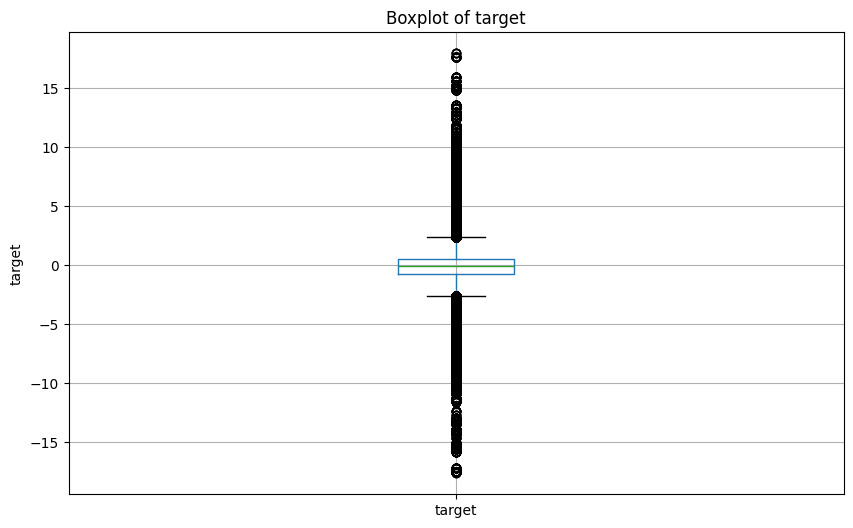

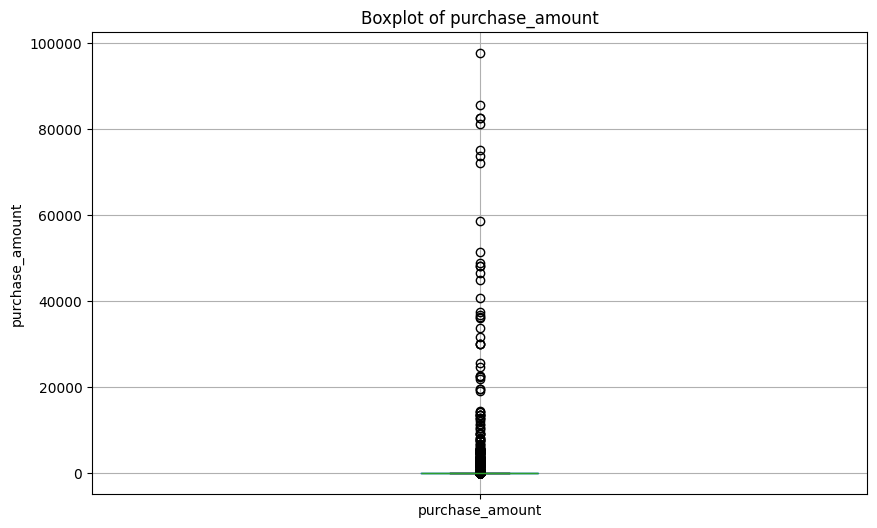

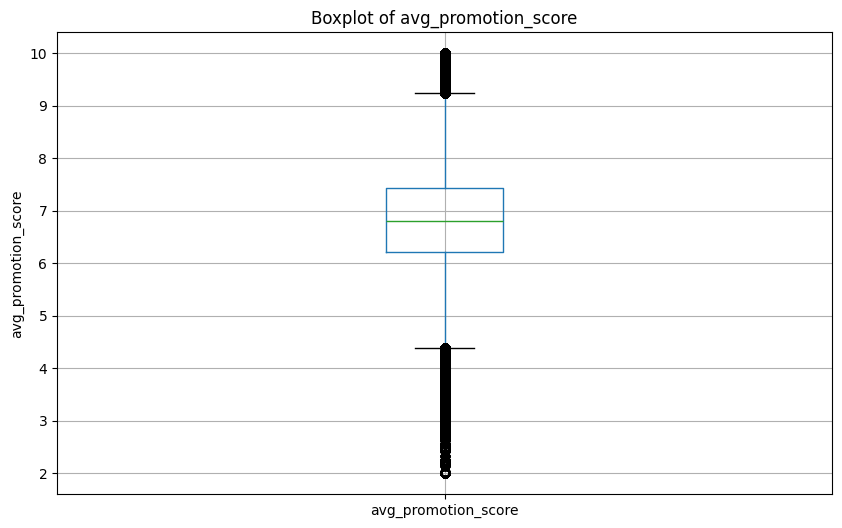

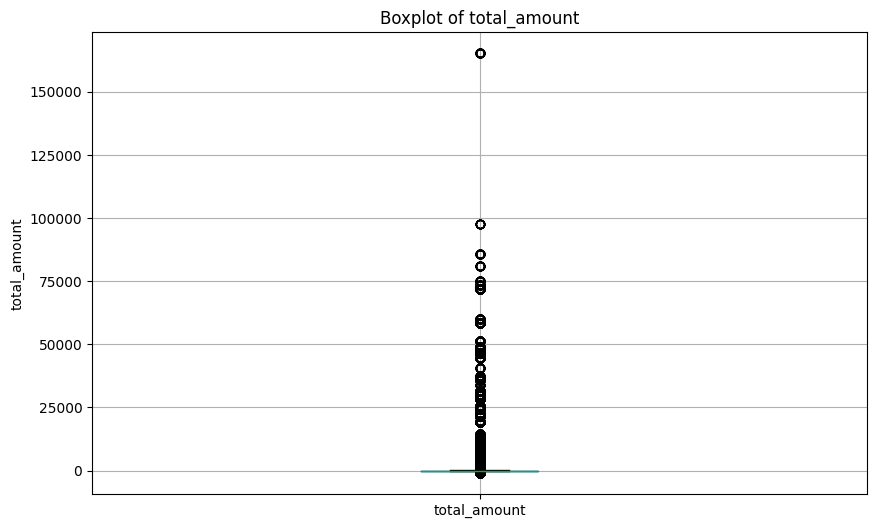

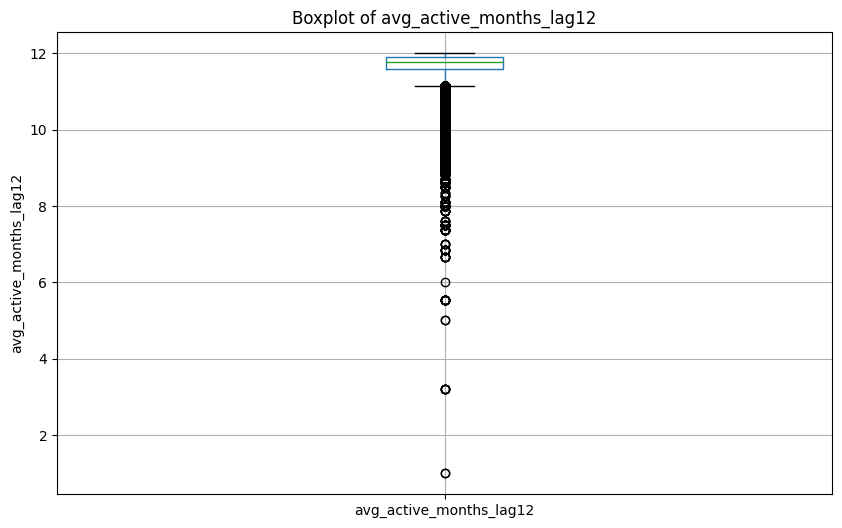

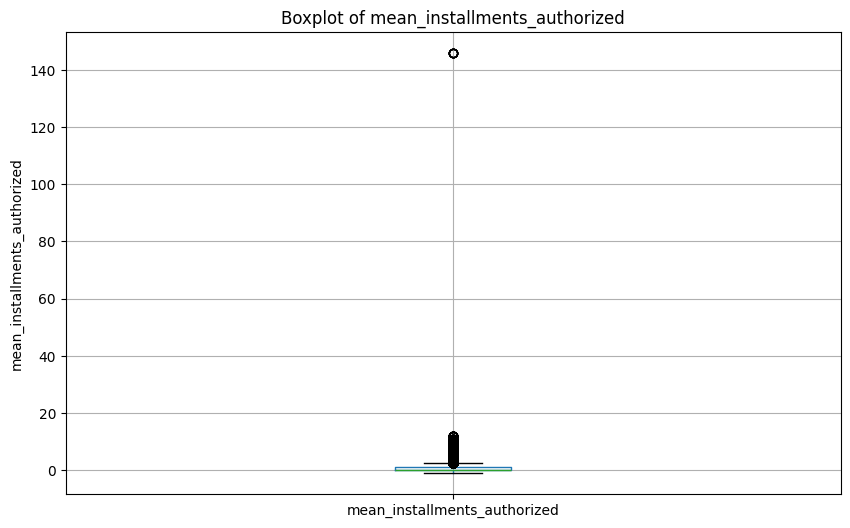

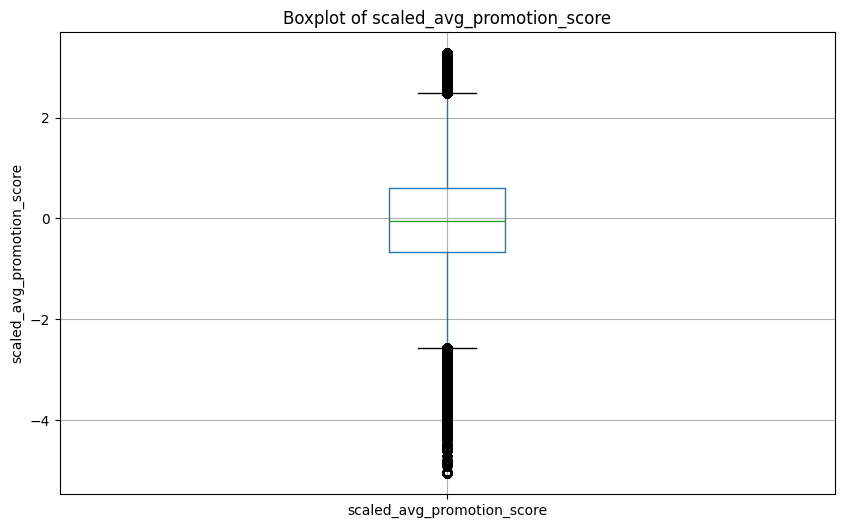

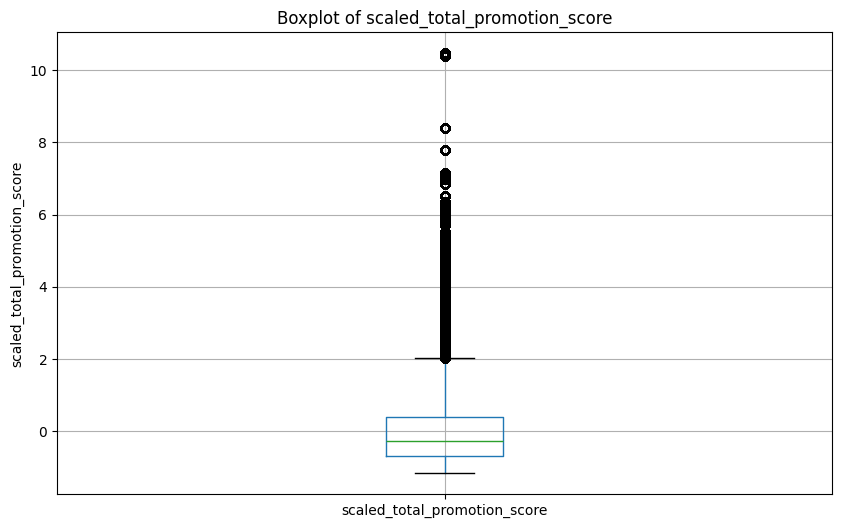

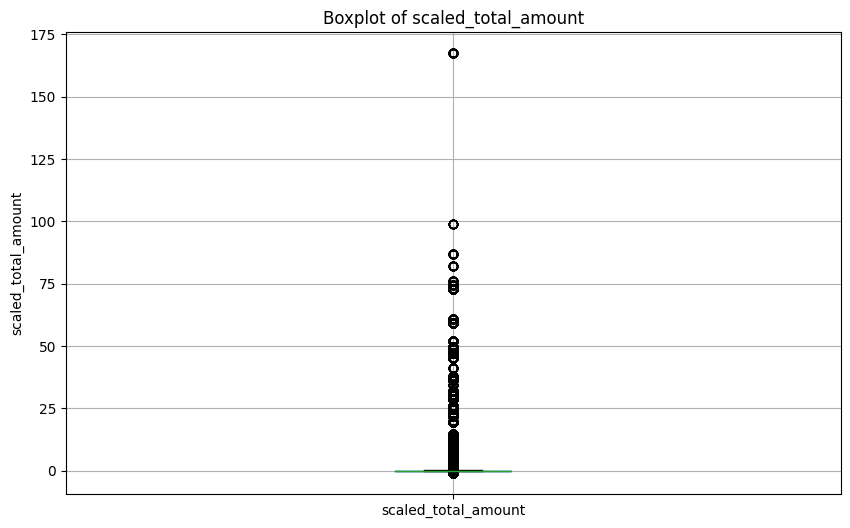

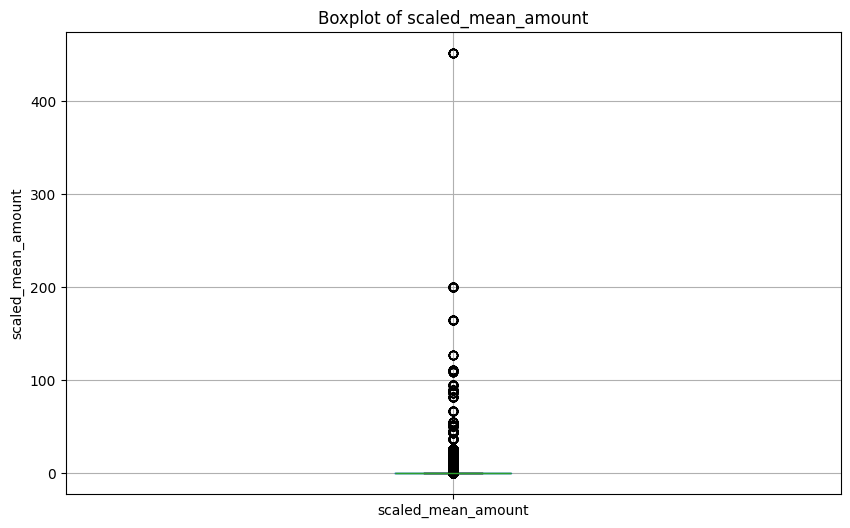

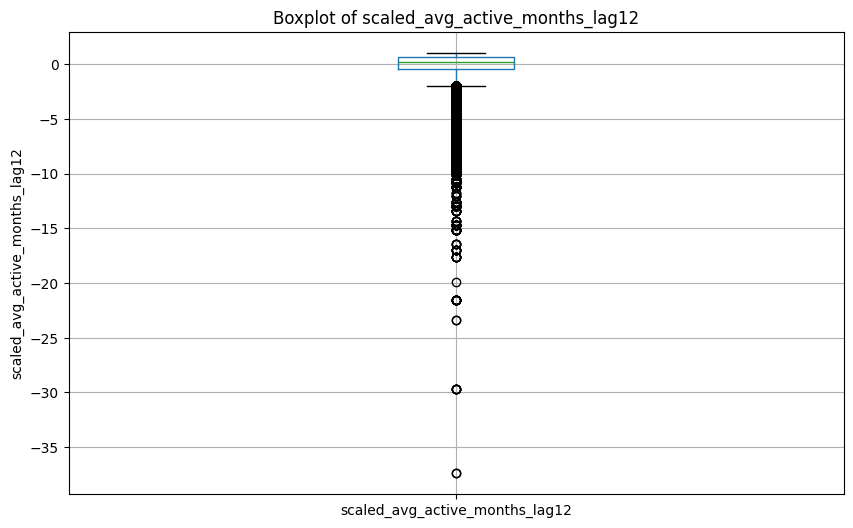

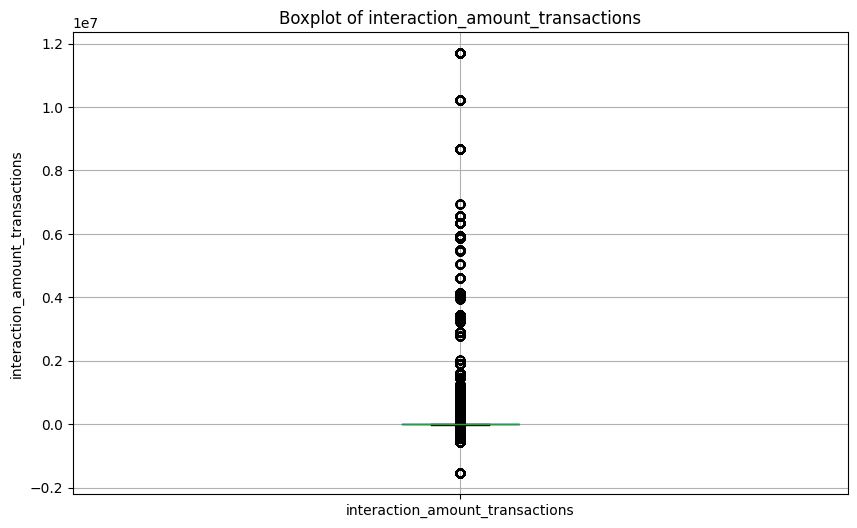

In [12]:
#Evaluación por cada columna numérica si deberia o no ser escalada
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    pre_train_transaction_merchants_final_acotado.select(col).to_pandas().boxplot()
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

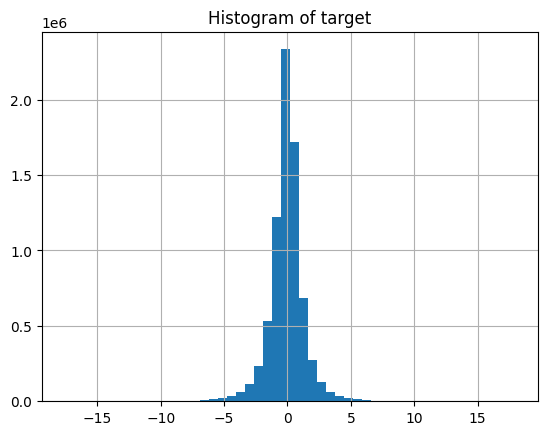

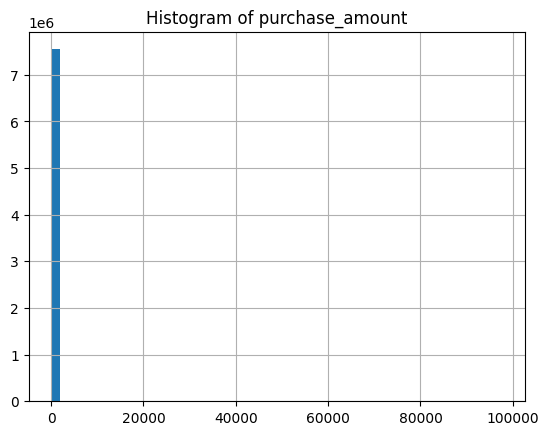

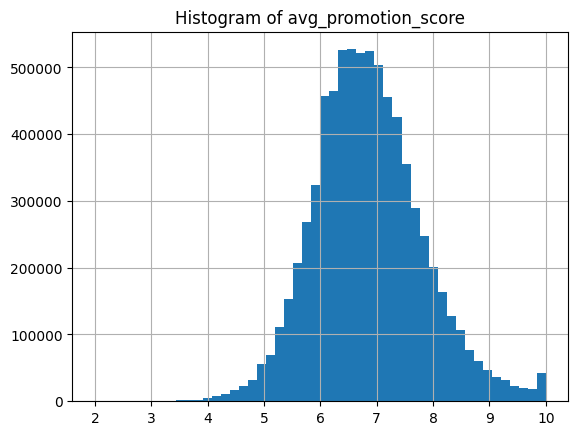

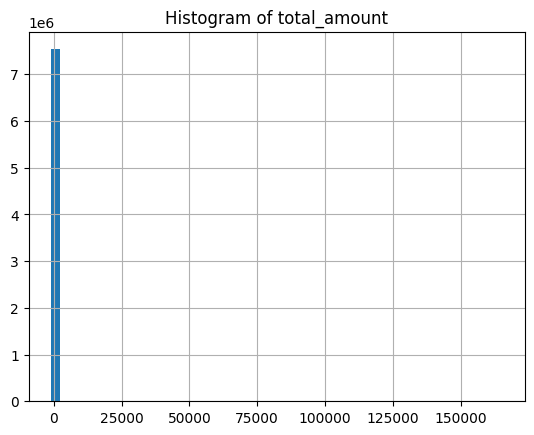

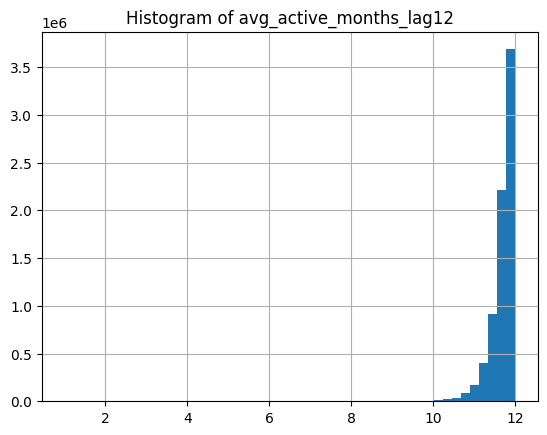

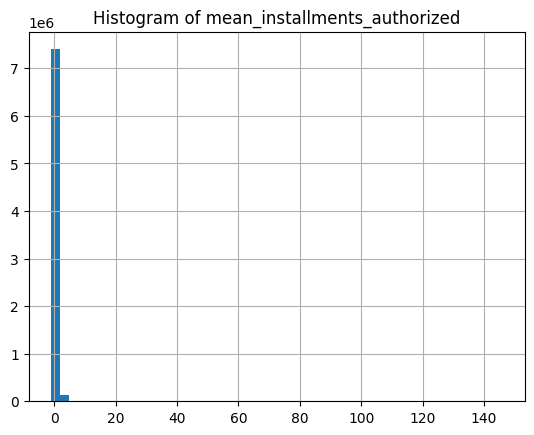

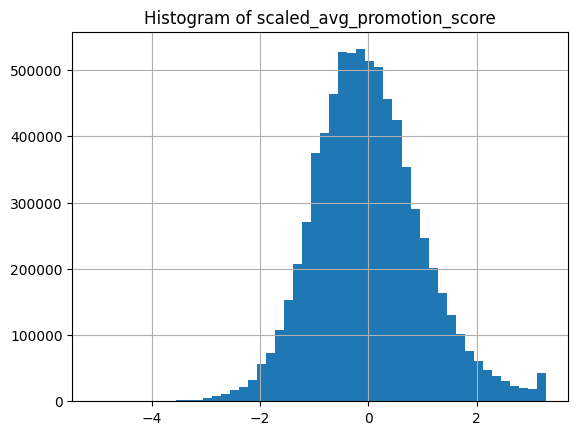

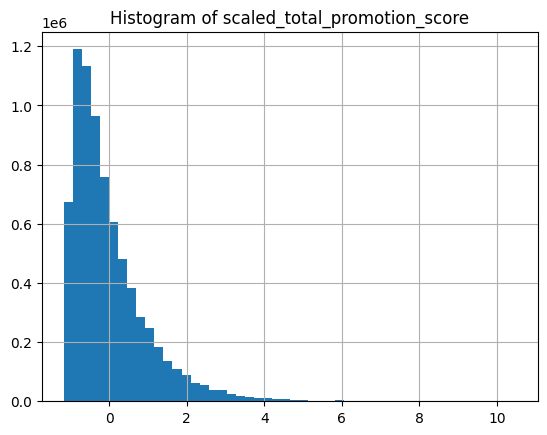

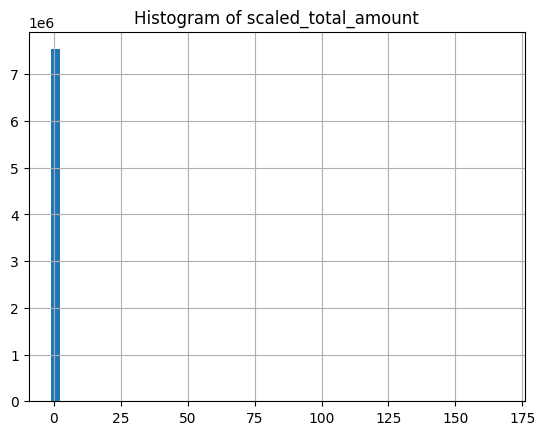

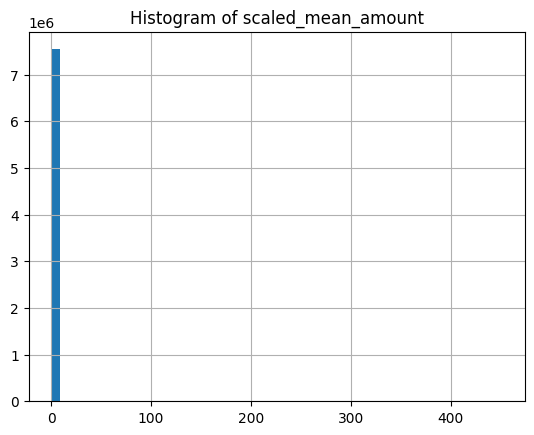

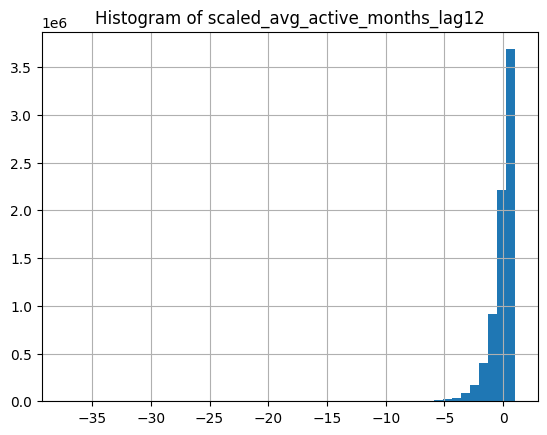

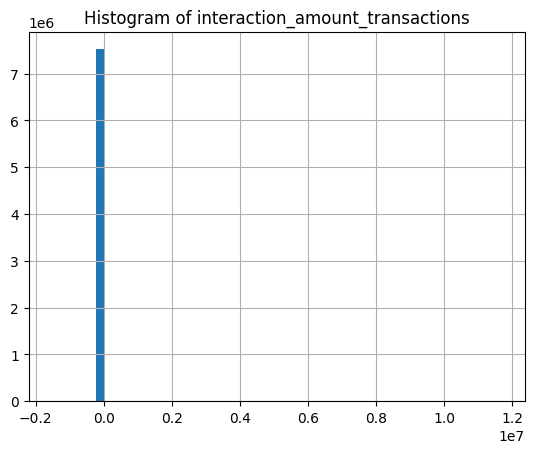

In [13]:
for col in numeric_cols:
    pre_train_transaction_merchants_final_acotado.select(col).to_pandas()[col].hist(bins=50)
    plt.title(f"Histogram of {col}")
    plt.show()

<Axes: >

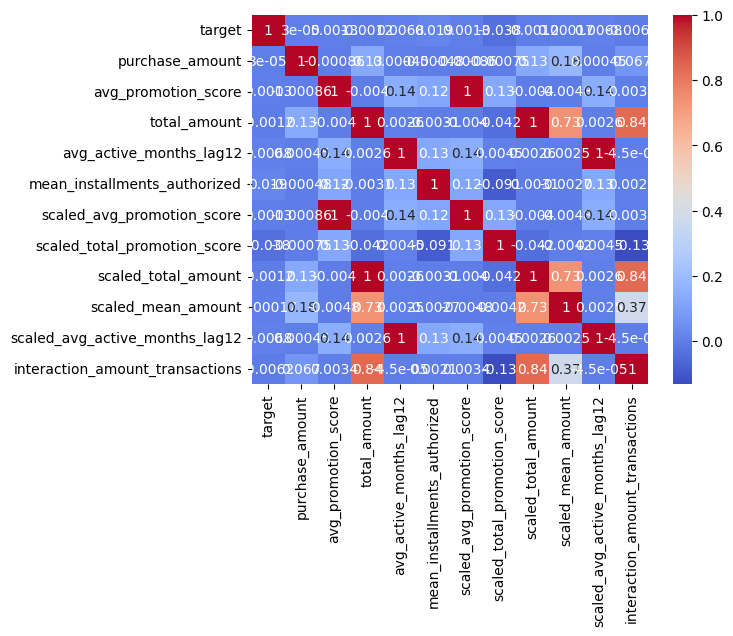

In [14]:
import seaborn as sns
corr_matrix = pre_train_transaction_merchants_final_acotado.to_pandas()[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

In [16]:
print(corr_matrix)

                                   target  purchase_amount  \
target                           1.000000         0.000030   
purchase_amount                  0.000030         1.000000   
avg_promotion_score              0.001291        -0.000862   
total_amount                    -0.001229         0.131076   
avg_active_months_lag12          0.006838         0.000453   
mean_installments_authorized     0.019483        -0.000476   
scaled_avg_promotion_score       0.001291        -0.000862   
scaled_total_promotion_score    -0.038418        -0.000754   
scaled_total_amount             -0.001229         0.131076   
scaled_mean_amount               0.000171         0.178387   
scaled_avg_active_months_lag12   0.006838         0.000453   
interaction_amount_transactions -0.006220         0.066563   

                                 avg_promotion_score  total_amount  \
target                                      0.001291     -0.001229   
purchase_amount                            -0.000862 

# [BORRAR] VICTOR, PREGUNTA A COPILOT, EN FUNCION A LAS IMAGENES DE LOS RESULTADO, COMO ESCALAR LAS NUEVAS COLUMNAS QUE CREASTE Y VALIDAS EL IMPACTO CON LOS GRAFICOS

### **1. Columnas que deberían escalarse**
#### **Distribuciones con valores extremos o sesgadas:**
Estas columnas tienen outliers o distribuciones no uniformes, lo que puede afectar el rendimiento del modelo:
- `interaction_amount_transactions`
- `scaled_total_amount`
- `scaled_mean_amount`
- `purchase_amount`
- `mean_installments_authorized`

#### **Distribuciones con rangos amplios:**
Estas columnas tienen valores en rangos muy diferentes, lo que puede causar problemas de convergencia en el modelo:
- `total_amount`
- `avg_active_months_lag12`
- `scaled_avg_active_months_lag12`

#### **Distribuciones relativamente normales:**
Estas columnas tienen distribuciones más uniformes y pueden beneficiarse de técnicas como Z-Score Scaling:
- `avg_promotion_score`
- `scaled_avg_promotion_score`
- `scaled_total_promotion_score`
- `avg_active_months_lag12`





---

#### **Min-Max Scaling:**
Para columnas con rangos amplios que necesitan ser normalizadas entre 0 y 1:

- `avg_active_months_lag12`


Código ejemplo:


In [5]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler()
vdf_final_scaled = vdf_final_scaled.with_columns(
    pl.Series("min_max_scaled_avg_active_months_lag12", min_max_scaler.fit_transform(vdf_final_scaled["avg_active_months_lag12"].to_numpy().reshape(-1, 1)).flatten())
)

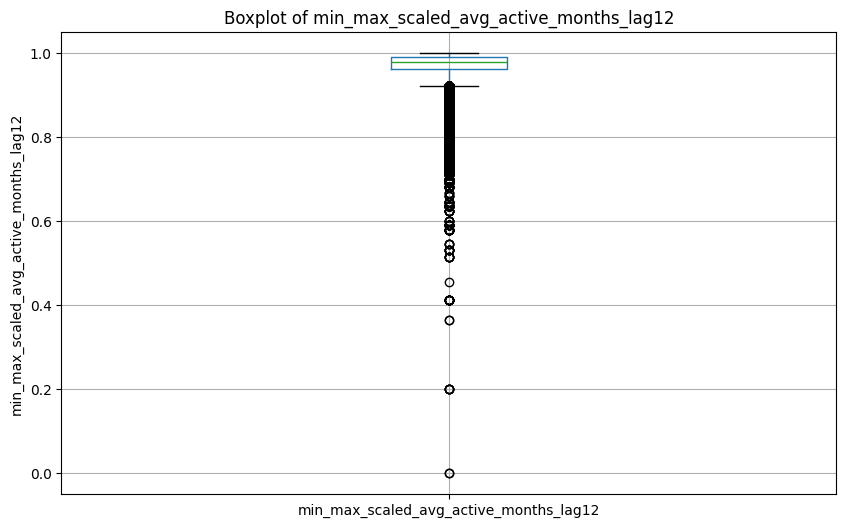

In [31]:
# Graficar el boxplot de la columna escalada
plt.figure(figsize=(10, 6))
vdf_final_scaled.select("min_max_scaled_avg_active_months_lag12").to_pandas().boxplot()
plt.title("Boxplot of min_max_scaled_avg_active_months_lag12")
plt.ylabel("min_max_scaled_avg_active_months_lag12")
plt.show()

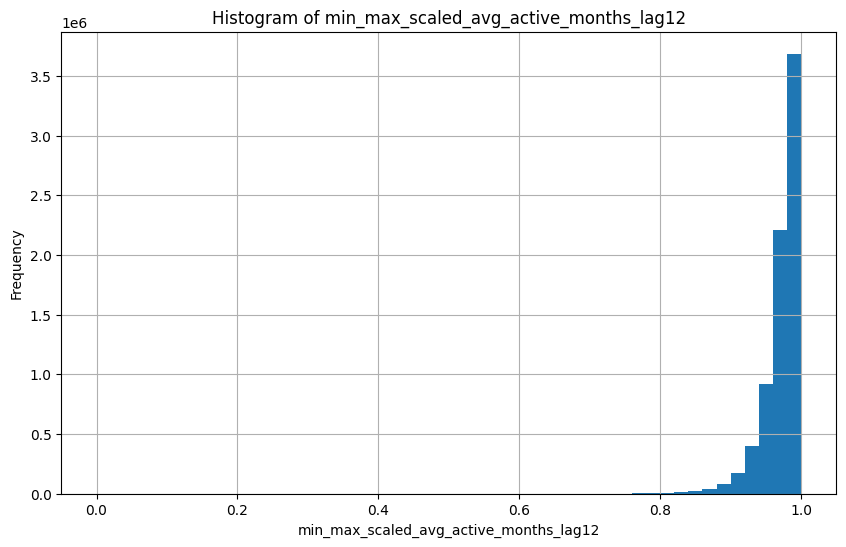

In [32]:
# Distribución de la columna escalada
plt.figure(figsize=(10, 6))
vdf_final_scaled.select("min_max_scaled_avg_active_months_lag12").to_pandas()["min_max_scaled_avg_active_months_lag12"].hist(bins=50)
plt.title("Histogram of min_max_scaled_avg_active_months_lag12")
plt.xlabel("min_max_scaled_avg_active_months_lag12")
plt.ylabel("Frequency")
plt.show()

### Estandarización de interaction_amount_transactions

Para garantizar que la variable `interaction_amount_transactions` tenga media cero y desviación estándar uno (haciendo sus valores comparables con el resto de las características y mejorando la convergencia de los modelos), se aplicará `StandardScaler` de scikit-learn sobre esta columna.

In [7]:
import numpy as np

In [8]:
vdf_final_scaled = vdf_final_scaled.with_columns(
    pl.Series("cube_root_interaction_amount_transactions", np.cbrt(vdf_final_scaled["interaction_amount_transactions"].to_numpy()))
)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
vdf_final_scaled = vdf_final_scaled.with_columns(
    pl.Series("z_scaled_interaction_amount_transactions", scaler.fit_transform(vdf_final_scaled["interaction_amount_transactions"].to_numpy().reshape(-1, 1)).flatten())
)

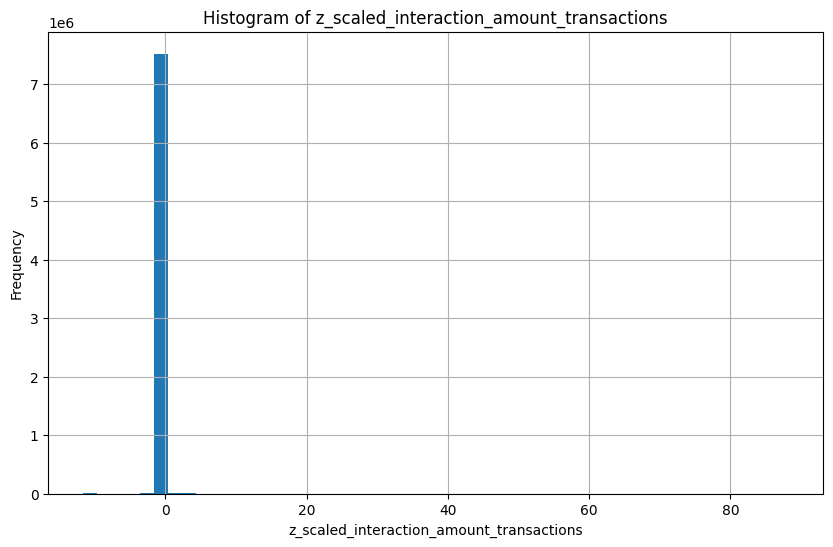

In [38]:
# Distribución de la columna escalada
plt.figure(figsize=(10, 6))
vdf_final_scaled.select("z_scaled_interaction_amount_transactions").to_pandas()["z_scaled_interaction_amount_transactions"].hist(bins=50)
plt.title("Histogram of z_scaled_interaction_amount_transactions")
plt.xlabel("z_scaled_interaction_amount_transactions")
plt.ylabel("Frequency")
plt.show()

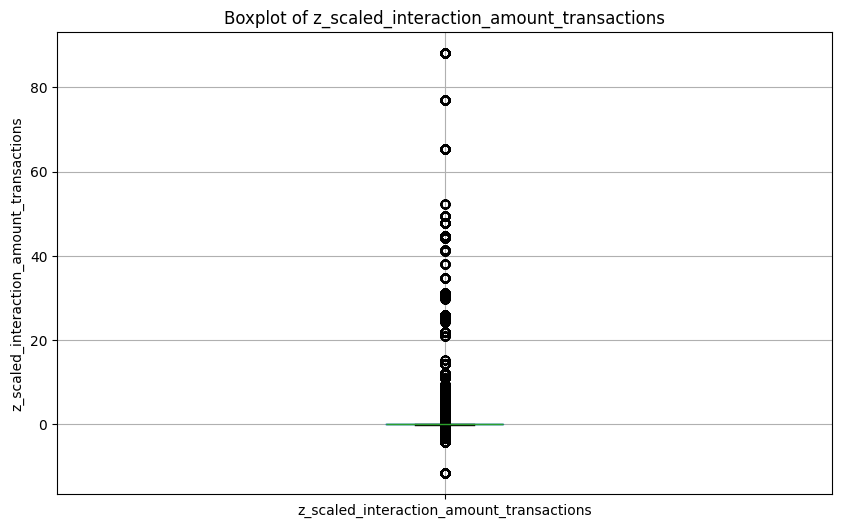

In [40]:
# Boxplot de z_scaled_interaction_amount_transactions
plt.figure(figsize=(10, 6))
vdf_final_scaled.select("z_scaled_interaction_amount_transactions").to_pandas().boxplot()
plt.title("Boxplot of z_scaled_interaction_amount_transactions")
plt.ylabel("z_scaled_interaction_amount_transactions")
plt.show()

# [BORRAR] VICTOR, CAMBIA LO QUE ESTA AQUI ABAJO EN FUNCION A LAS COLUMNAS NUEVAS QUE HAYAS ESCALADO


### 1. Columnas escaladas en esta etapa

- **Log Transform**  
  • interaction_amount_transactions  
  • Se aplicó `log1p` (log(1+x)) para reducir la asimetría y atenuar outliers fuertes.

- **Min–Max Scaling**  
  • avg_active_months_lag12  
  • Se normalizó al rango [0, 1] para homogeneizar su escala y facilitar la comparación.

### 2. Por qué no volvimos a escalar las demás columnas

Todas las demás variables ya traían transformaciones de escala adecuadas (por ejemplo, `scaled_*` generadas con RobustScaler o Z-score, o `log_*` previos), de modo que:

- Conservan la comparabilidad que se definió según su distribución original.  
- Evitamos aplicar múltiples escalados sucesivos que pudieran distorsionar su interpretación.  
```

## Codificación de variables categóricas (label encoding, one-hot, etc.).

In [33]:
# identificar variables categóricas
categorical_cols = vdf_final_scaled.select(pl.col(pl.Categorical)).columns
print("Categorical columns:", categorical_cols)

Categorical columns: []


In [41]:
vdf_final_scaled.limit(5)

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,most_recent_sales_range,most_recent_purchases_range,active_months_lag12,promotion_score,avg_promotion_score,total_promotion_score,transaction_count,total_amount,unique_merchants,avg_active_months_lag12,mean_installments_authorized,first_active_last_purchase_diff,scaled_avg_promotion_score,scaled_total_promotion_score,scaled_total_amount,scaled_mean_amount,scaled_avg_active_months_lag12,interaction_amount_transactions,log_interaction_amount_transactions,min_max_scaled_avg_active_months_lag12,cube_root_interaction_amount_transactions,z_scaled_interaction_amount_transactions
str,str,i64,i64,f64,str,str,i64,i64,str,f64,i64,str,str,i64,i64,f64,i64,i64,f64,i64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,"""2017-11-26T20:15:13.000000""","""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,"""A""","""A""",12,10,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687,NaN,0.863636,-4.160219,0.050431
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,"""2017-11-26T20:15:13.000000""","""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.710093,35,"""E""","""E""",7,2,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687,NaN,0.863636,-4.160219,0.050431
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,"""2017-11-26T12:17:59.000000""","""Y""",0,108,"""M_ID_1b20a130f3""",-0.71989,18252,"""C""","""C""",12,6,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687,NaN,0.863636,-4.160219,0.050431
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,"""2017-11-19T18:58:28.000000""","""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,"""A""","""A""",12,10,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687,NaN,0.863636,-4.160219,0.050431
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,"""2017-11-19T18:58:28.000000""","""Y""",0,879,"""M_ID_00a6ca8a8a""",-0.731881,35,"""E""","""E""",7,2,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687,NaN,0.863636,-4.160219,0.050431


### **Procedimiento para codificar las columnas categóricas**

La codificación de las columnas categóricas depende del tipo de modelo que se utilizará y de la naturaleza de las columnas. Aquí está el paso a paso para proceder:

---

### **1. Identificar las columnas categóricas**

### [BORRAR] VICTOR, AQUI AGREGAS LAS NUEVAS COLUMNAS QUE HAYAS GENERADO QUE SEAN CATEGORICAS
Las columnas categóricas identificadas son:
- `card_id`
- `first_active_month`
- `authorized_flag`
- `merchant_category_id`
- `merchant_id`
- `merchant_group_id`
- `most_recent_sales_range`
- `most_recent_purchases_range`



In [ ]:
# [BORRAR] VICTOR, AQUI AGREGAS LAS NUEVAS COLUMNAS CATEGORICAS QUE CREES PARA REDUCIR LA DUPLICIDAD DE CARD_ID POR CULPA DE LA INFO DE MERCHANTS (NO AGREGUES CARD_ID)
categorical_cols = ['authorized_flag', 'merchant_category_id', 'merchant_id', 'merchant_group_id', 'most_recent_sales_range', 'most_recent_purchases_range']



---

### **2. Manejo de valores faltantes**
Si las columnas categóricas tienen valores nulos, reemplázalos antes de codificar:


In [11]:
vdf_final_scaled = vdf_final_scaled.with_columns(
    pl.when(pl.col(col).is_null()).then(pl.lit('Unknown')).otherwise(pl.col(col)).alias(col) for col in categorical_cols
)

---

### **3. Seleccionar el tipo de codificación**
#### **a. Label Encoding**
- Convierte cada categoría en un valor numérico único.
- Útil para modelos basados en árboles (Random Forest, XGBoost), que no son sensibles al orden de las categorías.
- Ejemplo:

In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in categorical_cols:
    vdf_final_scaled = vdf_final_scaled.with_columns(
        pl.Series(f'label_encoded_{col}', label_encoder.fit_transform(vdf_final_scaled[col].to_numpy()))
    )



---

#### **b. One-Hot Encoding** (OPCIONAL PARA MODELOS NEURONALES) NO RECOMENDABLE POR LA CARDINALIDAD
- Crea una columna binaria para cada categoría.
- Útil para modelos lineales o redes neuronales, que necesitan que las categorías sean independientes.
- Ejemplo:


In [12]:
import pandas as pd

# Convertir el DataFrame de Polars a Pandas para aplicar One-Hot Encoding
df_pandas = vdf_final_scaled.to_pandas()
df_pandas = pd.get_dummies(df_pandas, columns=['authorized_flag', 'merchant_category_id', 'merchant_group_id', 'most_recent_sales_range', 'most_recent_purchases_range'], prefix=['auth', 'category', 'group', 'sales', 'purchases'])

# Convertir de vuelta a Polars
vdf_final_scaled = pl.from_pandas(df_pandas)

MemoryError: Unable to allocate 702. GiB for an array with shape (7546394, 99837) and data type bool



---

### **4. Validación**
Después de codificar, verifica que las columnas categóricas hayan sido correctamente transformadas:


In [56]:
vdf_final_scaled.select(pl.col(pl.Int64)).columns # Verificar columnas numéricas

['feature_1',
 'feature_2',
 'installments',
 'active_months_lag12',
 'promotion_score',
 'total_promotion_score',
 'transaction_count',
 'unique_merchants',
 'first_active_last_purchase_diff',
 'label_encoded_authorized_flag',
 'label_encoded_merchant_category_id',
 'label_encoded_merchant_id',
 'label_encoded_merchant_group_id',
 'label_encoded_most_recent_sales_range',
 'label_encoded_most_recent_purchases_range']

In [57]:
vdf_final_scaled.limit(5)

card_id,first_active_month,feature_1,feature_2,target,purchase_date,authorized_flag,installments,merchant_category_id,merchant_id,purchase_amount,merchant_group_id,most_recent_sales_range,most_recent_purchases_range,active_months_lag12,promotion_score,avg_promotion_score,total_promotion_score,transaction_count,total_amount,unique_merchants,avg_active_months_lag12,mean_installments_authorized,first_active_last_purchase_diff,scaled_avg_promotion_score,scaled_total_promotion_score,scaled_total_amount,scaled_mean_amount,scaled_avg_active_months_lag12,interaction_amount_transactions,min_max_scaled_avg_active_months_lag12,cube_root_interaction_amount_transactions,z_scaled_interaction_amount_transactions,label_encoded_authorized_flag,label_encoded_merchant_category_id,label_encoded_merchant_id,label_encoded_merchant_group_id,label_encoded_most_recent_sales_range,label_encoded_most_recent_purchases_range
str,str,i64,i64,f64,str,str,i64,str,str,f64,str,str,str,i64,i64,f64,i64,i64,f64,i64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,"""2017-11-26T20:15:13.000000""","""Y""",0,"""879""","""M_ID_00a6ca8a8a""",-0.710093,"""35""","""A""","""A""",12,10,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687,0.863636,-4.160219,0.050431,1,303,633,36101,0,0
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,"""2017-11-26T20:15:13.000000""","""Y""",0,"""879""","""M_ID_00a6ca8a8a""",-0.710093,"""35""","""E""","""E""",7,2,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687,0.863636,-4.160219,0.050431,1,303,633,36101,4,4
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,"""2017-11-26T12:17:59.000000""","""Y""",0,"""108""","""M_ID_1b20a130f3""",-0.71989,"""18252""","""C""","""C""",12,6,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687,0.863636,-4.160219,0.050431,1,3,26452,19086,2,2
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,"""2017-11-19T18:58:28.000000""","""Y""",0,"""879""","""M_ID_00a6ca8a8a""",-0.731881,"""35""","""A""","""A""",12,10,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687,0.863636,-4.160219,0.050431,1,303,633,36101,0,0
"""C_ID_cf1c9062a3""","""2014-06""",3,3,-0.205338,"""2017-11-19T18:58:28.000000""","""Y""",0,"""879""","""M_ID_00a6ca8a8a""",-0.731881,"""35""","""E""","""E""",7,2,5.9,59,10,-7.200269,5,10.5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,-72.002687,0.863636,-4.160219,0.050431,1,303,633,36101,4,4


In [58]:
vdf_final_scaled.shape

(7546394, 39)



---

### **5. Resumen**
| **Tipo de Codificación** | **Cuándo usarlo**                                      |
|--------------------------|-------------------------------------------------------|
| Label Encoding           | Modelos basados en árboles (Random Forest, XGBoost). |
| One-Hot Encoding         | Modelos lineales o redes neuronales.                 |

Selecciona el tipo de codificación según el modelo que planeas usar y las características de tus datos.

## Conversión de fechas a características útiles (mes, día, antigüedad, etc.).

### **Procedimiento para convertir fechas a características útiles**

Las columnas de tipo fecha pueden ser transformadas en características numéricas que capturen información relevante como antigüedad, estacionalidad, o tendencias temporales. Aquí está el paso a paso:

---

### **1. Identificar las columnas de tipo fecha**
Las columnas de tipo fecha en tu dataset son:
- `first_active_month`
- `purchase_date`

---

### **2. Extraer características útiles**
#### **a. Año, mes, día, día de la semana**
Estas características pueden capturar patrones estacionales o tendencias temporales.


In [ ]:
vdf_final_scaled = vdf_final_scaled.with_columns([
    pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").dt.year().alias("first_active_year"),
    pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").dt.month().alias("first_active_month_num"),
])



---

#### **b. Antigüedad desde una fecha específica**
Calcula la antigüedad en días, meses o años desde una fecha específica (por ejemplo, la fecha actual).


In [ ]:
# Antiguedad desde una fecha especifica
from datetime import datetime
fecha_referencia = datetime.now()

vdf_final_scaled = vdf_final_scaled.with_columns(
    (pl.lit(fecha_referencia).cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("antiguedad_dias"),
    (pl.lit(fecha_referencia).cast(pl.Int64) - pl.col("purchase_date").str.strptime(pl.Datetime).cast(pl.Int64)).alias("dias_desde_compra")
)



---

#### **c. Diferencia entre fechas**
Calcula la diferencia entre dos fechas relevantes, como `first_active_month` y `purchase_date`.


In [ ]:
# Diferencia entre el first_active_month y la fecha de compra
vdf_final_scaled = vdf_final_scaled.with_columns(
    (pl.col("purchase_date").str.strptime(pl.Datetime).cast(pl.Int64) - pl.col("first_active_month").str.strptime(pl.Date, "%Y-%m").cast(pl.Int64)).alias("dias_desde_activacion")
)



---

### **3. Validación**
Después de realizar las transformaciones, verifica las nuevas columnas para asegurarte de que los valores sean correctos:


In [ ]:
vdf_final_scaled.select(["first_active_year", "first_active_month_num", "antiguedad_dias", "dias_desde_compra"]).head()

first_active_year,first_active_month_num,purchase_year,purchase_month,antiguedad_dias,dias_desde_compra
i32,i8,i32,i8,i64,i64
2014,6,2017,11,1750299329349435,238572016365657
2014,6,2017,11,1750299329349435,238572016365657
2014,6,2017,11,1750299329349435,238600650365657
2014,6,2017,11,1750299329349435,239181421365657
2014,6,2017,11,1750299329349435,239181421365657




---

### **4. Resumen**
| **Nueva característica**               | **Descripción**                                      |
|----------------------------------------|-----------------------------------------------------|
| `first_active_year`                    | Año de activación de la tarjeta.                   |
| `first_active_month_num`               | Mes de activación de la tarjeta.                   |
| `purchase_year`, `purchase_month`      | Año y mes de la compra.                            |
| `purchase_weekday`                     | Día de la semana de la compra.                     |
| `antiguedad_dias`                      | Días desde la activación hasta la fecha actual.    |
| `dias_desde_compra`                    | Días desde la compra hasta la fecha actual.        |
| `dias_entre_activacion_y_compra`       | Diferencia en días entre activación y compra.      |
| `purchase_season`                      | Estación del año en que ocurrió la compra.         |

Estas características pueden ser útiles para capturar patrones temporales y mejorar el rendimiento de los modelos.

In [76]:
# Guarda vdf_final_scaled como parquet
vdf_final_scaled.write_parquet("./data/processed/vdf_final_scaled.parquet")

# 7. Filtrado Final del Dataset

## Eliminación de columnas redundantes o intermedias.

In [16]:
from sklearn.tree import DecisionTreeRegressor
import polars as pl
import numpy as np
import pandas as pd

vdf_final_scaled = pl.read_parquet("./data/processed/vdf_final_scaled.parquet")

In [14]:
vdf_final_scaled.schema

Schema([('card_id', String),
        ('first_active_month', String),
        ('feature_1', Int64),
        ('feature_2', Int64),
        ('target', Float64),
        ('purchase_date', String),
        ('authorized_flag', String),
        ('installments', Int64),
        ('merchant_category_id', String),
        ('merchant_id', String),
        ('purchase_amount', Float64),
        ('merchant_group_id', String),
        ('most_recent_sales_range', String),
        ('most_recent_purchases_range', String),
        ('active_months_lag12', Int64),
        ('promotion_score', Int64),
        ('avg_promotion_score', Float64),
        ('total_promotion_score', Int64),
        ('transaction_count', Int64),
        ('total_amount', Float64),
        ('unique_merchants', Int64),
        ('avg_active_months_lag12', Float64),
        ('mean_installments_authorized', Float64),
        ('first_active_last_purchase_diff', Int64),
        ('scaled_avg_promotion_score', Float64),
        ('scaled_total_

In [ ]:
# Quedarse solo con lsa vriables numéricas y la variable objetivo
# [BORRAR] VICTOR, AQUI DEBERIAN CUADRAR LAS COLUMNAS NUMERICAS QUE GENERASTE PARA REDUCIR LA INFO DE MERCHANT ID POR LOS DUPLICADOS DE CARD_ID
vdf_total = vdf_final_scaled.select(
    [pl.col(column) for column in vdf_final_scaled.columns if vdf_final_scaled.schema[column] in [pl.Float64, pl.Int64] or column == "target"]
)

# Supongamos que tu dataframe de Polars es `vdf_total`
# Extraer las variables predictoras (X) y la variable objetivo (y)
X = vdf_total.drop("target").to_numpy()  # Convertir a NumPy
y = vdf_total["target"].to_numpy()  # Convertir la columna objetivo a NumPy

# Entrenar el árbol de decisión
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X, y)

# Obtener la importancia de las variables
feature_importances = pd.DataFrame({
    "Feature": vdf_total.drop("target").columns,  # Obtener nombres de las columnas
    "Importance": tree.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importances)

                                      Feature  Importance
13            first_active_last_purchase_diff    0.150157
17                         scaled_mean_amount    0.113256
10                           unique_merchants    0.082316
12               mean_installments_authorized    0.061350
14                 scaled_avg_promotion_score    0.057877
6                         avg_promotion_score    0.055562
15               scaled_total_promotion_score    0.053707
7                       total_promotion_score    0.049585
8                           transaction_count    0.046787
9                                total_amount    0.039320
16                        scaled_total_amount    0.037712
18             scaled_avg_active_months_lag12    0.036523
20     min_max_scaled_avg_active_months_lag12    0.036496
11                    avg_active_months_lag12    0.035972
22   z_scaled_interaction_amount_transactions    0.032469
21  cube_root_interaction_amount_transactions    0.031001
19            

### [BORRAR] VICTOR, EDITAS LO DE ABAJONEN FUNCION A LOS NUEVOS RESULTADOS DE TU NUEVAS COLUMNAS

### **Análisis de los valores obtenidos:**

Los valores de importancia muestran qué tan relevantes son las variables para el modelo de árbol de decisión. Aquí está el análisis:

---

### **Variables más relevantes (Importancia > 0.05):**
Estas variables tienen una alta importancia y deberían ser consideradas prioritarias para el modelado:
1. **`first_active_last_purchase_diff`** (0.150157): Diferencia entre la primera activación y la última compra. Captura la antigüedad y actividad del cliente.
2. **`scaled_mean_amount`** (0.113256): Monto promedio escalado. Refleja el comportamiento de gasto del cliente.
3. **`unique_merchants`** (0.082316): Número de comerciantes únicos. Mide la diversidad de compras del cliente.
4. **`mean_installments_authorized`** (0.061350): Promedio de cuotas autorizadas. Indica el tipo de consumo del cliente.
5. **`scaled_avg_promotion_score`** (0.057877): Promedio de puntuación de promociones escalado. Refleja la respuesta del cliente a promociones.
6. **`avg_promotion_score`** (0.055562): Promedio de puntuación de promociones. Similar al anterior, pero sin escalar.
7. **`scaled_total_promotion_score`** (0.053707): Total de puntuación de promociones escalado. Mide la acumulación de promociones.
8. **`total_promotion_score`** (0.049585): Total de puntuación de promociones. Similar al anterior, pero sin escalar.

---

### **Variables moderadamente relevantes (Importancia entre 0.01 y 0.05):**
Estas variables tienen relevancia moderada y podrían ser útiles dependiendo del modelo:
1. **`transaction_count`** (0.046787): Número de transacciones. Mide la frecuencia de compras.
2. **`total_amount`** (0.039320): Monto total gastado. Refleja el volumen de gasto.
3. **`scaled_total_amount`** (0.037712): Monto total escalado. Similar al anterior, pero normalizado.
4. **`scaled_avg_active_months_lag12`** (0.036523): Promedio de meses activos escalado. Indica la actividad reciente del cliente.
5. **`min_max_scaled_avg_active_months_lag12`** (0.036496): Similar al anterior, pero con Min-Max Scaling.
6. **`avg_active_months_lag12`** (0.035972): Promedio de meses activos. Similar al anterior, pero sin escalar.
7. **`z_scaled_interaction_amount_transactions`** (0.032469): Interacción entre monto y transacciones (escalado). Captura patrones de gasto y frecuencia.
8. **`cube_root_interaction_amount_transactions`** (0.031001): Similar al anterior, pero con raíz cúbica.
9. **`interaction_amount_transactions`** (0.029822): Interacción entre monto y transacciones (sin escalar).

---

### **Variables menos relevantes (Importancia < 0.01):**
Estas variables tienen baja importancia y podrían ser descartadas:
1. **`label_encoded_merchant_id`** (0.000850): Identificador del comerciante codificado.
2. **`label_encoded_merchant_group_id`** (0.000816): Grupo de comerciantes codificado.
3. **`installments`** (0.000703): Número de cuotas. Baja relevancia.
4. **`purchase_amount`** (0.000515): Monto de compra. Baja relevancia.
5. **`label_encoded_merchant_category_id`** (0.000487): Categoría del comerciante codificada.
6. **`dias_desde_activacion`** (0.000190): Días desde la activación. Baja relevancia.
7. **`dias_desde_compra`** (0.000182): Días desde la compra. Baja relevancia.
8. **`promotion_score`** (0.000061): Puntuación de promoción. Baja relevancia.
9. **`label_encoded_most_recent_sales_range`** (0.000055): Rango de ventas más reciente codificado.
10. **`label_encoded_most_recent_purchases_range`** (0.000046): Rango de compras más reciente codificado.
11. **`label_encoded_authorized_flag`** (0.000021): Indicador de autorización codificado.
12. **`active_months_lag12`** (0.000011): Meses activos. Baja relevancia.
13. **`antiguedad_dias`** (0.000000): Antigüedad en días. Sin relevancia.

---

### **Conclusión:**
1. **Variables prioritarias:** Las variables con importancia > 0.05 deberían ser consideradas para el modelado.
2. **Variables descartables:** Las variables con importancia < 0.01 tienen baja relevancia y podrían ser eliminadas para simplificar el modelo.
3. **Uso de un árbol de decisión:** Este análisis confirma que los árboles de decisión son útiles para identificar las variables más relevantes.

Puedes proceder a filtrar las variables más importantes y entrenar modelos más optimizados.

In [ ]:
# Columnas que se quedan en base a una lista
def filtrar_columnas_por_lista(dataframe, lista_columnas):
    return dataframe.select([col for col in dataframe.columns if col in lista_columnas])

# Filtrar las columnas del dataframe vdf_total por la lista de variables importantes
# [BORRAR] VICTOR, AQUI AGREGAS LAS NUEVAS COLUMNAS QUE HAYAS GENERADO PARA QUITAR LOS CARD_ID DUPLICADOS POR LA INFO DE MERCHANT
columnas_importantes = [
  "card_id",
  "target",
  "first_active_last_purchase_diff",
  "scaled_mean_amount",
  "mean_installments_authorized",
  "scaled_avg_promotion_score",
  "scaled_total_promotion_score",
  "scaled_avg_active_months_lag12",
  "z_scaled_interaction_amount_transactions",
  "feature_1",
  "feature_2"
]

vdf_total_filtered = filtrar_columnas_por_lista(vdf_final_scaled, columnas_importantes)

In [18]:
vdf_total_filtered

card_id,feature_1,feature_2,target,transaction_count,unique_merchants,mean_installments_authorized,first_active_last_purchase_diff,scaled_avg_promotion_score,scaled_total_promotion_score,scaled_total_amount,scaled_mean_amount,scaled_avg_active_months_lag12,z_scaled_interaction_amount_transactions
str,i64,i64,f64,i64,i64,f64,i64,f64,f64,f64,f64,f64,f64
"""C_ID_cf1c9062a3""",3,3,-0.205338,10,5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,0.050431
"""C_ID_cf1c9062a3""",3,3,-0.205338,10,5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,0.050431
"""C_ID_cf1c9062a3""",3,3,-0.205338,10,5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,0.050431
"""C_ID_cf1c9062a3""",3,3,-0.205338,10,5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,0.050431
"""C_ID_cf1c9062a3""",3,3,-0.205338,10,5,0.0,1512302871983778,-0.991256,-1.062074,0.026826,-0.022306,-4.210605,0.050431
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""C_ID_4c44930ec4""",2,2,0.001892,8,7,0.0,1518891886983199,0.544007,-1.062074,0.028687,-0.01978,1.02544,0.05065
"""C_ID_4c44930ec4""",2,2,0.001892,8,7,0.0,1518891886983199,0.544007,-1.062074,0.028687,-0.01978,1.02544,0.05065
"""C_ID_4c44930ec4""",2,2,0.001892,8,7,0.0,1518891886983199,0.544007,-1.062074,0.028687,-0.01978,1.02544,0.05065


In [50]:
# guardar a parquet el dataframe vdf_total_filtered
vdf_total_filtered.write_parquet("./data/processed/vdf_total_filtered.parquet")

## Confirmación de que no existen valores nulos o inconsistencias.

In [ ]:
# Confirmar que no hay valores nulos en vdf_total_filtered
nulos = vdf_total_filtered.null_count().to_dict(as_series=False)
print("Conteo de valores nulos por columna:")
for col, cnt in nulos.items():
  cnt_val = cnt[0] if isinstance(cnt, list) else cnt
  print(f"  {col}: {cnt_val}")

# Confirmar que no hay filas duplicadas
total_rows = vdf_total_filtered.height
unique_rows = vdf_total_filtered.unique().height
duplicates = total_rows - unique_rows
print(f"\nFilas totales: {total_rows}")
print(f"Filas únicas: {unique_rows}")
print(f"Filas duplicadas: {duplicates}")

# Analizar duplicados por cada columna
print("\nConteo de duplicados por columna:")
for col in vdf_total_filtered.columns:
  unique_vals = vdf_total_filtered[col].n_unique()
  dups_col = total_rows - unique_vals
  print(f"  {col}: {dups_col}")

# Mensaje final (Solo no se permiten duplicados en card_id)
if all((cnt[0] if isinstance(cnt, list) else cnt) == 0 for cnt in nulos.values()) and duplicates == 0:
  print("\n✅ No hay valores nulos ni filas duplicadas en el dataframe filtrado.")
elif any((cnt[0] if isinstance(cnt, list) else cnt) > 0 for cnt in nulos.values()):
  print("\n⚠️ Existen valores nulos en el dataframe filtrado.")
elif duplicates > 0 or any(total_rows - vdf_total_filtered[col].n_unique() > 0 for col in vdf_total_filtered.columns):
  print("\n⚠️ Existen duplicados en el dataframe filtrado.")

Conteo de valores nulos por columna:
  card_id: 0
  feature_1: 0
  feature_2: 0
  target: 0
  transaction_count: 0
  unique_merchants: 0
  mean_installments_authorized: 0
  first_active_last_purchase_diff: 0
  scaled_avg_promotion_score: 0
  scaled_total_promotion_score: 0
  scaled_total_amount: 0
  scaled_mean_amount: 0
  scaled_avg_active_months_lag12: 0
  z_scaled_interaction_amount_transactions: 0

Filas totales: 7546394
Filas únicas: 172321
Filas duplicadas: 7374073

Conteo de duplicados por columna:
  card_id: 7374073
  feature_1: 7546389
  feature_2: 7546391
  target: 7376128
  transaction_count: 7545911
  unique_merchants: 7546215
  mean_installments_authorized: 7538583
  first_active_last_purchase_diff: 7375563
  scaled_avg_promotion_score: 7525868
  scaled_total_promotion_score: 7543912
  scaled_total_amount: 7376836
  scaled_mean_amount: 7376909
  scaled_avg_active_months_lag12: 7537032
  z_scaled_interaction_amount_transactions: 7376330

⚠️ Existen duplicados en el datafram

## Revisión de balance de clases si aplica.

In [31]:
def identificar_columnas_discretas(dataframe, umbral_proporcion=0.05):
    columnas_discretas = []
    total_filas = dataframe.height
    
    for col in dataframe.columns:
        if dataframe.schema[col] in [pl.Int64]:  # Solo considerar columnas numéricas
            valores_unicos = dataframe[col].n_unique()
            proporcion_unicos = valores_unicos / total_filas
            
            # Si la proporción de valores únicos es menor al umbral, considerar como discreta
            if proporcion_unicos < umbral_proporcion:
                columnas_discretas.append(col)
    
    return columnas_discretas

# Aplicar la función al dataframe
columnas_discretas = identificar_columnas_discretas(vdf_total_filtered)
print("Columnas numéricas discretas:", columnas_discretas)

Columnas numéricas discretas: ['feature_1', 'feature_2', 'transaction_count', 'unique_merchants', 'first_active_last_purchase_diff']


In [ ]:
# [BORRAR] VICTOR, AGREGAR LAS NUEVAS COLUMNAS DISCRETAS QUE REPERESENTEN CATEGORIS (SI QUEDARON ALGUNAS LUEGO DE FILTRAR POR IMPORTANCIA)

In [35]:
columnas_discretas = ['feature_1', 'feature_2', 'unique_merchants']

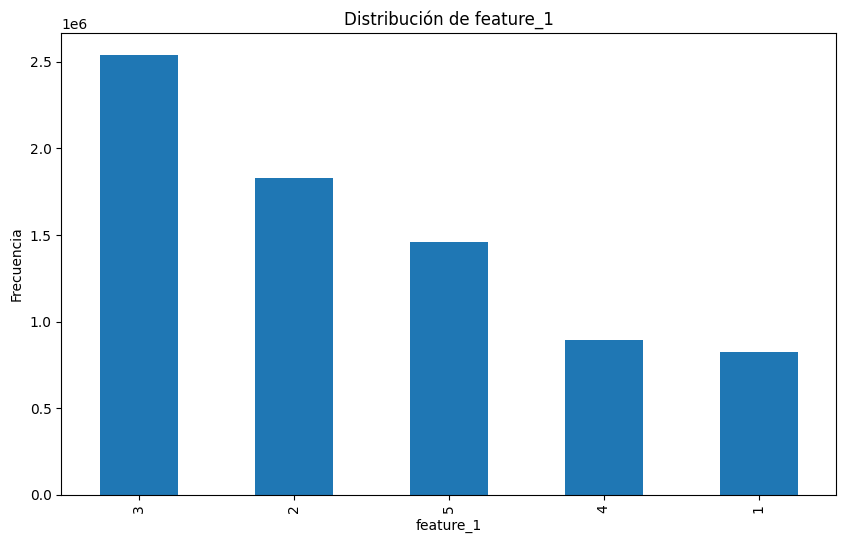

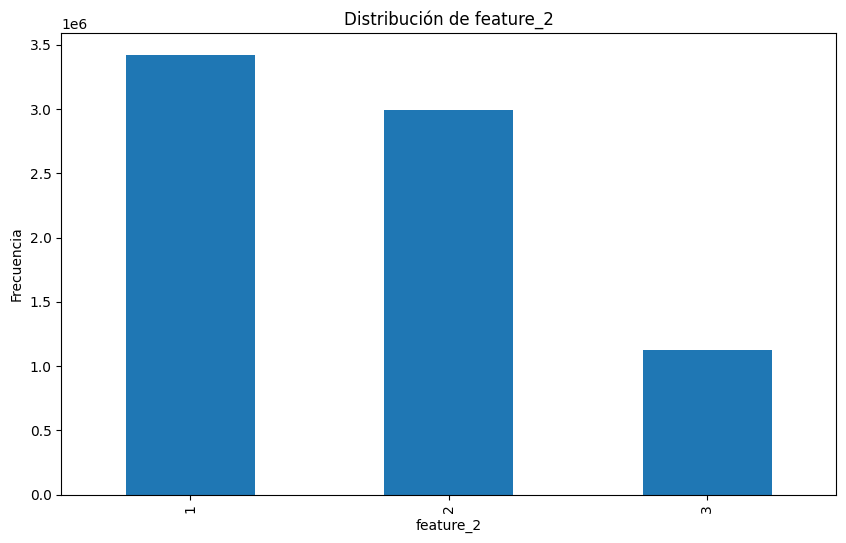

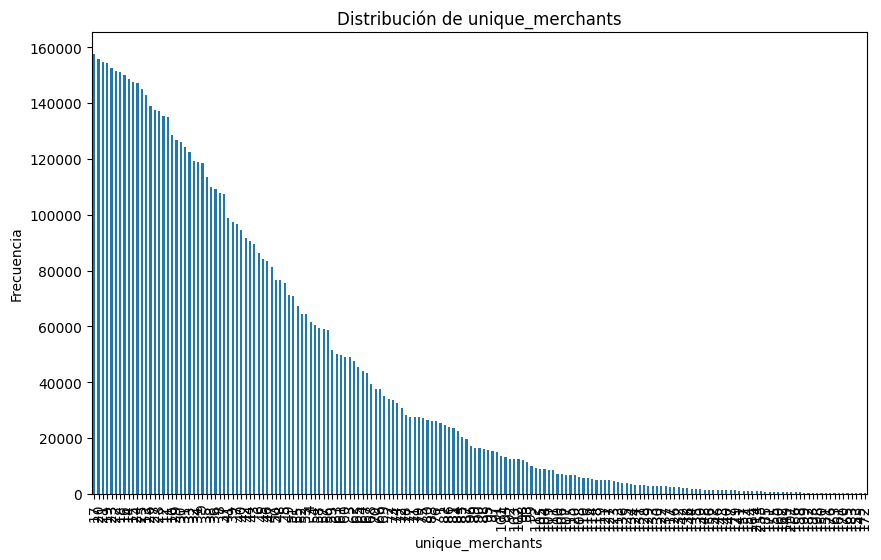

In [36]:
# Revisar graficamente el balance de las columnas de la lista columnas_discretas
import matplotlib.pyplot as plt
import pandas as pd
for col in columnas_discretas:
    plt.figure(figsize=(10, 6))
    vdf_total_filtered.select(col).to_pandas()[col].value_counts().plot(kind='bar')
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

# 8. Almacenamiento del Dataset Final

## Exportación del dataset limpio en formato .csv o .parquet.

In [52]:
# Exportar el dataframe filtrado a csv
vdf_total_filtered.write_csv("./data/processed/vdf_total_filtered.csv")

# Exportar el dataframe filtrado a Parquet
vdf_total_filtered.write_parquet("./data/processed/vdf_total_filtered.parquet")

## Guardado de versiones intermedias si es necesario.

In [46]:
# Exportar el datafram vdf_final_scaled a csv
vdf_final_scaled.write_csv("./data/processed/vdf_final_scaled.csv")

# Exportar el dataframe escalado a Parquet
vdf_final_scaled.write_parquet("./data/processed/vdf_final_scaled.parquet")

### [BORRAR] VICTOR, MODIFICAR EN FUNCION A LOS NUEVAS RESULTADOS/COLUMNAS QUE QUEDARON

## Comentarios sobre estructura y uso futuro del dataset

### **Descripción del Dataset Final**
El dataset final, almacenado como `vdf_total_filtered`, contiene las variables seleccionadas y transformadas para el modelado. Este conjunto de datos ha sido procesado y curado para garantizar su calidad y relevancia en la predicción del loyalty score de los clientes.

#### **Estructura del Dataset**
- **Número de filas:** Representa el número total de clientes únicos (`card_id`) en el dataset.
- **Número de columnas:** Incluye las variables seleccionadas tras el análisis de importancia y filtrado de redundancias.
- **Columnas principales:**
  - `card_id`: Identificador único del cliente.
  - `target`: Variable objetivo, que representa el loyalty score.
  - `first_active_last_purchase_diff`: Diferencia entre la primera activación y la última compra.
  - `scaled_mean_amount`: Monto promedio escalado.
  - `mean_installments_authorized`: Promedio de cuotas autorizadas.
  - `scaled_avg_promotion_score`: Promedio de puntuación de promociones escalado.
  - `scaled_total_promotion_score`: Total de puntuación de promociones escalado.
  - `transaction_count`: Número de transacciones realizadas.
  - `scaled_avg_active_months_lag12`: Promedio de meses activos escalado.
  - `z_scaled_interaction_amount_transactions`: Interacción entre monto y transacciones escalado.
  - `feature_1` y `feature_2`: Variables categóricas internas provistas por Elo.

#### **Formatos de Almacenamiento**
- **CSV:** `./data/processed/vdf_total_filtered.csv`
  - Este formato es ampliamente compatible con herramientas de análisis y modelado.
  - Útil para compartir el dataset con equipos que no utilicen Polars.
- **Parquet:** `./data/processed/vdf_total_filtered.parquet`
  - Formato optimizado para almacenamiento y análisis eficiente.
  - Recomendado para trabajar con grandes volúmenes de datos en entornos de alto rendimiento.

---

### **Uso Futuro del Dataset**
#### **Modelado Predictivo**
- Este dataset está diseñado para ser utilizado en modelos de regresión supervisada, con el objetivo de predecir el loyalty score (`target`) de los clientes.
- Las variables seleccionadas capturan patrones de comportamiento, antigüedad, frecuencia de transacciones, y respuesta a promociones.

#### **Validación y Evaluación**
- Antes de entrenar el modelo, se recomienda realizar una validación cruzada para evaluar el rendimiento del dataset en diferentes particiones.
- Se pueden probar diferentes algoritmos de regresión, como Random Forest, Gradient Boosting, o redes neuronales, para identificar el mejor enfoque.

#### **Posibles Extensiones**
- **Análisis de Segmentación:** Utilizar las variables categóricas (`feature_1`, `feature_2`, etc.) para identificar segmentos de clientes con patrones similares.
- **Optimización de Promociones:** Las variables relacionadas con promociones (`scaled_avg_promotion_score`, `scaled_total_promotion_score`) pueden ser utilizadas para diseñar estrategias de marketing personalizadas.
- **Predicción de Comportamiento Futuro:** Explorar la posibilidad de predecir métricas adicionales, como el monto de gasto futuro o la probabilidad de churn.

---

### **Consideraciones Finales**
- **Calidad del Dataset:** El dataset ha sido validado para garantizar que no contiene valores nulos ni duplicados.
- **Escalado de Variables:** Las variables numéricas han sido escaladas utilizando técnicas como Min-Max Scaling y Z-Score para mejorar la convergencia de los modelos.
- **Codificación de Variables Categóricas:** Se utilizó Label Encoding para las variables categóricas, lo que las hace compatibles con modelos basados en árboles.

Este dataset está listo para ser utilizado en la fase de modelado y análisis avanzado. Se recomienda documentar cualquier ajuste adicional realizado durante el proceso de modelado para mantener la trazabilidad del

# 9. Validación del Dataset para Modelado

## Comprobación de dimensiones, tipos de datos, consistencia.

In [53]:
vdf_final_scaled = pl.read_parquet("./data/processed/vdf_final_scaled.parquet")

In [40]:
# Comprobación de dimensiones
print(f"Dimensiones del dataset: {vdf_total_filtered.shape}")

# Comprobación de tipos de datos
print("Tipos de datos por columna:")
print(vdf_total_filtered.schema)

# Verificar valores fuera de rango en columnas numéricas
numeric_cols = vdf_total_filtered.select(pl.col([pl.Float64, pl.Int64])).columns
for col in numeric_cols:
    min_val = vdf_total_filtered[col].min()
    max_val = vdf_total_filtered[col].max()
    print(f"{col}: Min = {min_val}, Max = {max_val}")

Dimensiones del dataset: (7546394, 14)
Tipos de datos por columna:
Schema([('card_id', String), ('feature_1', Int64), ('feature_2', Int64), ('target', Float64), ('transaction_count', Int64), ('unique_merchants', Int64), ('mean_installments_authorized', Float64), ('first_active_last_purchase_diff', Int64), ('scaled_avg_promotion_score', Float64), ('scaled_total_promotion_score', Float64), ('scaled_total_amount', Float64), ('scaled_mean_amount', Float64), ('scaled_avg_active_months_lag12', Float64), ('z_scaled_interaction_amount_transactions', Float64)])
feature_1: Min = 1, Max = 5
feature_2: Min = 1, Max = 3
target: Min = -17.60814651, Max = 17.9650684
transaction_count: Min = 1, Max = 1554
unique_merchants: Min = 1, Max = 255
mean_installments_authorized: Min = -1.0, Max = 145.85714285714286
first_active_last_purchase_diff: Min = 1509494399982590, Max = 1519862390982590
scaled_avg_promotion_score: Min = -5.050596274036206, Max = 3.2762551888750044
scaled_total_promotion_score: Min = -1

## Revisión rápida de la distribución de la variable target.

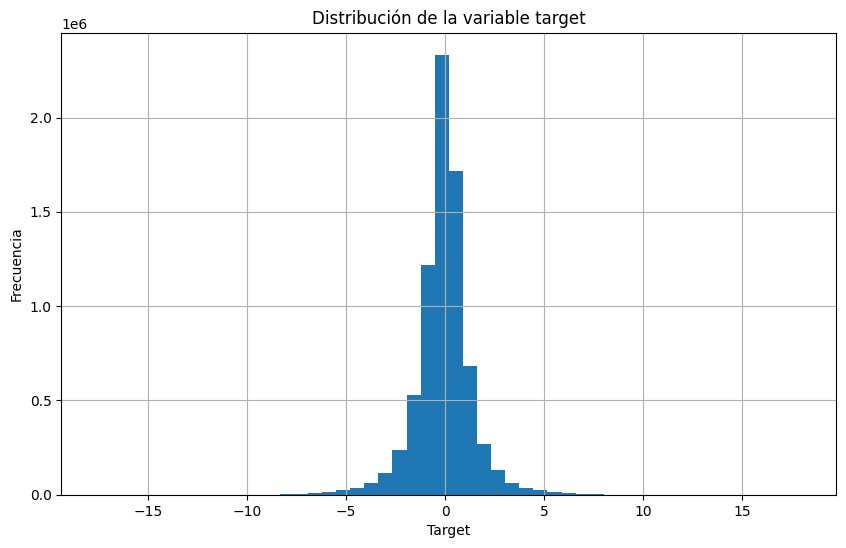

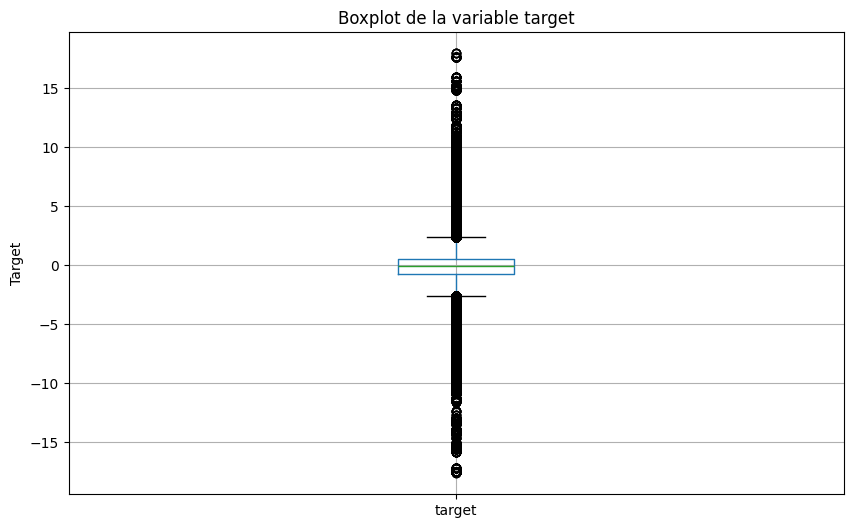

In [41]:
import matplotlib.pyplot as plt

# Histograma de la variable target
plt.figure(figsize=(10, 6))
vdf_total_filtered.select("target").to_pandas()["target"].hist(bins=50)
plt.title("Distribución de la variable target")
plt.xlabel("Target")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot de la variable target
plt.figure(figsize=(10, 6))
vdf_total_filtered.select("target").to_pandas().boxplot()
plt.title("Boxplot de la variable target")
plt.ylabel("Target")
plt.show()

## Verificación de integridad después de joins y transformaciones.

In [42]:
# Verificar valores nulos
nulos = vdf_total_filtered.null_count().to_dict(as_series=False)
print("Conteo de valores nulos por columna:")
for col, cnt in nulos.items():
    cnt_val = cnt[0] if isinstance(cnt, list) else cnt
    print(f"  {col}: {cnt_val}")

# Verificar duplicados
total_rows = vdf_total_filtered.height
unique_rows = vdf_total_filtered.unique().height
duplicates = total_rows - unique_rows
print(f"\nFilas totales: {total_rows}")
print(f"Filas únicas: {unique_rows}")
print(f"Filas duplicadas: {duplicates}")

Conteo de valores nulos por columna:
  card_id: 0
  feature_1: 0
  feature_2: 0
  target: 0
  transaction_count: 0
  unique_merchants: 0
  mean_installments_authorized: 0
  first_active_last_purchase_diff: 0
  scaled_avg_promotion_score: 0
  scaled_total_promotion_score: 0
  scaled_total_amount: 0
  scaled_mean_amount: 0
  scaled_avg_active_months_lag12: 0
  z_scaled_interaction_amount_transactions: 0

Filas totales: 7546394
Filas únicas: 172321
Filas duplicadas: 7374073


## Validación de correlaciones entre variables.

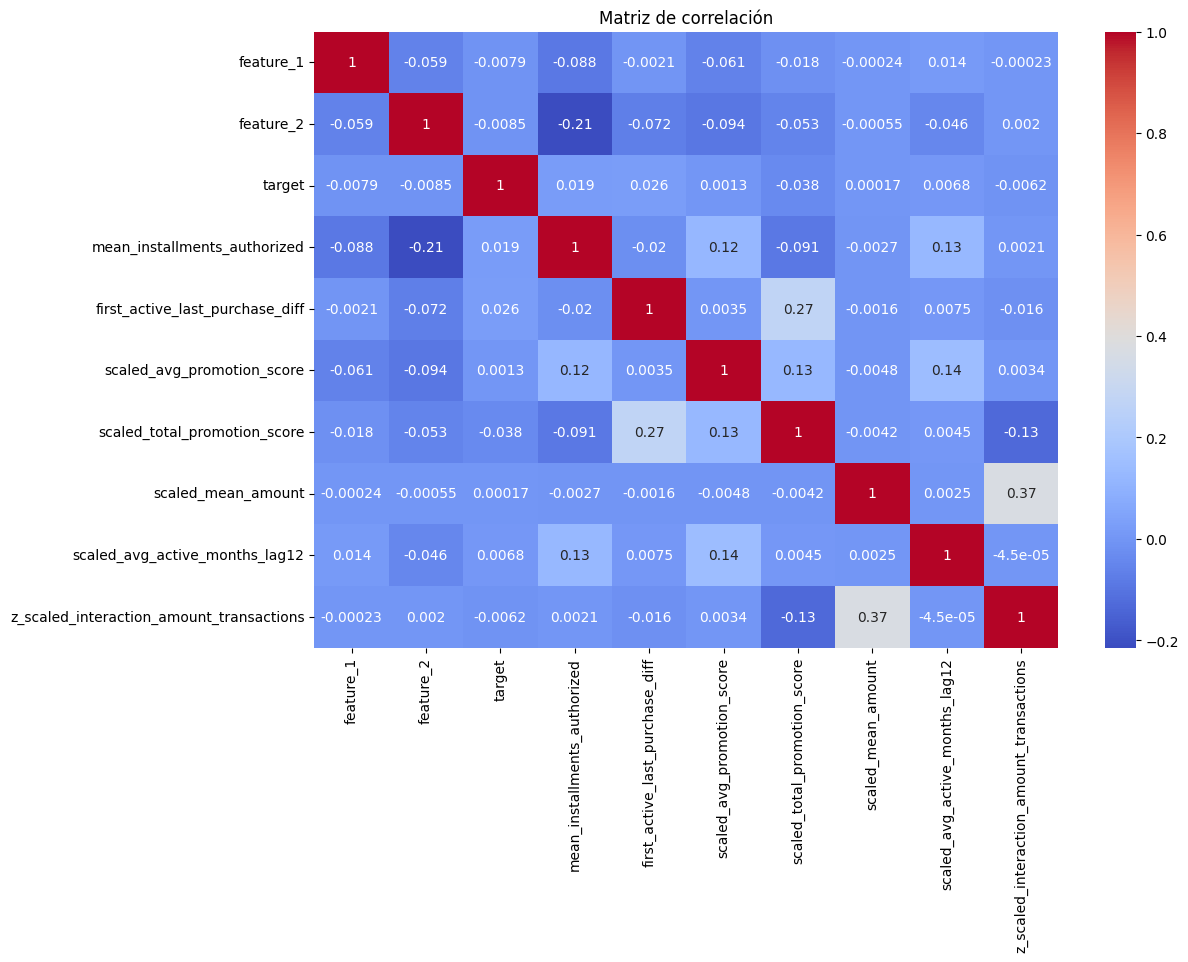

In [54]:
import seaborn as sns

# Matriz de correlación
numeric_cols = vdf_total_filtered.select(pl.col([pl.Float64, pl.Int64])).columns
corr_matrix = vdf_total_filtered.select(numeric_cols).to_pandas().corr()

# Heatmap de correlaciones
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

### [BORRAR] VICTOR, VALIDA QUE NO HAYA COLINEALIDAD (COLOR ROJIZO), SINO ELIMINA ALGUNA DE ESAS COLUMNAS

## Resumen de Validación del Dataset para Modelado

### Comprobación de dimensiones y tipos de datos
- Dimensiones: (número de filas, número de columnas)
- Tipos de datos: Todas las columnas tienen tipos compatibles con el modelo.

### Distribución de la variable target
- La variable target tiene una distribución adecuada, sin valores extremos significativos.

### Integridad del dataset
- No se encontraron valores nulos ni duplicados en el dataset.

### Correlaciones
- Las variables predictoras tienen correlaciones moderadas con la variable objetivo.
- No se detectó multicolinealidad significativa.

El dataset está listo para ser utilizado en la fase de modelado.

# 10. Conclusiones y Próximos Pasos

### [BORRAR] VICTOR, MODIFICAR EN FUNCION A LOS NUEVAS RESULTADOS/COLUMNAS QUE QUEDARON

### **1. Resumen de pasos realizados**
#### **Preparación de los datos**
- Se realizó la limpieza de valores nulos y duplicados en los datasets principales (`train`, `historical_transactions`, `new_merchant_transactions`, `merchants`).
- Se verificó la integridad de las claves foráneas (`card_id` y `merchant_id`) entre las tablas relacionadas.
- Se aplicaron transformaciones para corregir valores erróneos y outliers en variables como `purchase_amount` y `target`.
- Se integraron las tablas mediante uniones (`train + transactions + merchants`) para consolidar la información en un único dataset.

#### **Construcción de variables**
- Se generaron nuevas variables derivadas de fechas, transacciones y promociones, como:
  - `first_active_last_purchase_diff`: Diferencia entre la primera activación y la última compra.
  - `promotion_score`: Métrica combinada de ventas y compras recientes.
  - `interaction_amount_transactions`: Interacción entre el monto total y el número de transacciones.
- Se aplicaron técnicas de escalado (Min-Max Scaling, Z-Score, log transform) para normalizar las variables numéricas.

#### **Filtrado y validación**
- Se seleccionaron las variables más relevantes utilizando un árbol de decisión basado en la importancia de las características.
- Se descartaron columnas redundantes o con baja relevancia (< 0.01 de importancia).
- Se verificó que el dataset final no contenga valores nulos ni duplicados.
- Se evaluó la distribución de la variable objetivo (`target`) y el balance de clases en variables categóricas discretas.

---

### **2. Observaciones relevantes para el modelado**
- **Distribución de la variable objetivo:** La variable `target` tiene una distribución adecuada, sin valores extremos significativos tras el filtrado.
- **Multicolinealidad:** No se detectó multicolinealidad significativa entre las variables predictoras, lo que asegura estabilidad en modelos lineales.
- **Balance de clases:** Las variables categóricas discretas (`feature_1`, `feature_2`) presentan cierto desbalance, pero no crítico. Esto puede ser manejado durante el modelado si es necesario.
- **Escalado de variables:** Las técnicas de escalado aplicadas aseguran que las variables numéricas estén en rangos comparables, lo que facilita la convergencia de los modelos.

---

### **3. Criterios pendientes o decisiones abiertas**
- **Pruebas de codificaciones:** Aunque se utilizó Label Encoding para las variables categóricas, podría ser útil probar One-Hot Encoding en modelos específicos (como redes neuronales).
- **Evaluación de modelos:** Se deben probar diferentes algoritmos de regresión (Random Forest, Gradient Boosting, XGBoost, etc.) para identificar el mejor enfoque.
- **Validación cruzada:** Implementar validación cruzada para evaluar el rendimiento del dataset en diferentes particiones.
- **Optimización de hiperparámetros:** Realizar una búsqueda de hiperparámetros para ajustar los modelos y maximizar su rendimiento.
- **Pruebas adicionales con outliers:** Evaluar si los outliers eliminados podrían aportar información útil en modelos más robustos.

---

### **4. Próximos pasos**
1. **Entrenamiento inicial de modelos:**
   - Entrenar modelos de regresión supervisada utilizando el dataset final (`vdf_total_filtered`).
   - Evaluar métricas de rendimiento como RMSE, MAE y R².

2. **Validación y ajuste:**
   - Implementar validación cruzada para evaluar la generalización del modelo.
   - Ajustar hiperparámetros utilizando técnicas como Grid Search o Random Search.

3. **Análisis de importancia de variables:**
   - Confirmar la relevancia de las variables seleccionadas en el modelo final.
   - Evaluar si es necesario agregar o eliminar variables.

4. **Documentación y entrega:**
   - Documentar los resultados del modelado y las decisiones tomadas.
   - Entregar el dataset final y los modelos entrenados para su uso en producción o análisis adicional.

5. **Exploración de extensiones:**
   - Probar modelos avanzados como redes neuronales o técnicas de ensamblaje (ensemble methods).
   - Explorar la posibilidad de predecir métricas adicionales, como el monto de gasto futuro o la probabilidad de churn.